In [1]:
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from PIL import Image
import pandas as pd
import seaborn as sns

In [2]:
trainingSetpath = "./trainingSample/trainingSample"
images_mnist = {}

for folder in os.listdir(trainingSetpath):  # Use trainingSetpath_path here
    folder_path = os.path.join(trainingSetpath, folder)
    if os.path.isdir(folder_path):
        images1= []
        for filename in os.listdir(folder_path):
            if filename.endswith((".png", ".jpg", ".jpeg")):
                img = Image.open(os.path.join(folder_path, filename))
                img = img.convert("RGB")
                img = img.resize((224, 224))
                images1.append(np.array(img)) 

        if images1:  # Ensure non-empty images list before converting
            images_mnist[folder] = np.array(images1)

# Print shape of each folder's image set
for folder, images in  images_mnist.items():
    print(f"Folder: {folder}, Images Shape: {images.shape}")

Folder: 0, Images Shape: (60, 224, 224, 3)
Folder: 1, Images Shape: (60, 224, 224, 3)
Folder: 2, Images Shape: (60, 224, 224, 3)
Folder: 3, Images Shape: (60, 224, 224, 3)
Folder: 4, Images Shape: (60, 224, 224, 3)
Folder: 5, Images Shape: (60, 224, 224, 3)
Folder: 6, Images Shape: (60, 224, 224, 3)
Folder: 7, Images Shape: (60, 224, 224, 3)
Folder: 8, Images Shape: (60, 224, 224, 3)
Folder: 9, Images Shape: (60, 224, 224, 3)


In [3]:
dataCoil20_path = "./coil-20"
images_coil = {}

for folder in os.listdir(dataCoil20_path):  # Use dataCoil20_path here
    folder_path = os.path.join(dataCoil20_path, folder)
    if os.path.isdir(folder_path):
        images1= []
        for filename in os.listdir(folder_path):
            if filename.endswith((".png", ".jpg", ".jpeg")):
                img = Image.open(os.path.join(folder_path, filename))
                img = img.convert("RGB")
                img = img.resize((224, 224))
                images1.append(np.array(img))

        if images1:  # Ensure non-empty images list before converting
            images_coil[folder] = np.array(images1)

# Print shape of each folder's image set
for folder, images in images_coil.items():
    print(f"Folder: {folder}, Images Shape: {images.shape}")

Folder: 1, Images Shape: (72, 224, 224, 3)
Folder: 10, Images Shape: (72, 224, 224, 3)
Folder: 11, Images Shape: (72, 224, 224, 3)
Folder: 12, Images Shape: (72, 224, 224, 3)
Folder: 13, Images Shape: (72, 224, 224, 3)
Folder: 14, Images Shape: (72, 224, 224, 3)
Folder: 15, Images Shape: (72, 224, 224, 3)
Folder: 16, Images Shape: (72, 224, 224, 3)
Folder: 17, Images Shape: (72, 224, 224, 3)
Folder: 18, Images Shape: (72, 224, 224, 3)
Folder: 19, Images Shape: (72, 224, 224, 3)
Folder: 2, Images Shape: (72, 224, 224, 3)
Folder: 20, Images Shape: (72, 224, 224, 3)
Folder: 3, Images Shape: (72, 224, 224, 3)
Folder: 4, Images Shape: (72, 224, 224, 3)
Folder: 5, Images Shape: (72, 224, 224, 3)
Folder: 6, Images Shape: (72, 224, 224, 3)
Folder: 7, Images Shape: (72, 224, 224, 3)
Folder: 8, Images Shape: (72, 224, 224, 3)
Folder: 9, Images Shape: (72, 224, 224, 3)


In [4]:
files = {}
path = "./coil-20"
for i in range(20) : 
    im_path = path+f'/{i+1}'
    files[i] = []
    for j in range(72) : 
        files[i].append(im_path+f'\\obj{i+1}__{j}.png')


In [5]:
# Directory containing images
def from_img_togif(files, i=[1], dir='coil-20-gifs'): 
    try:
        # Create directory if it doesn't exist
        os.makedirs(dir, exist_ok=True)
        
        # Get full paths of images
        image_files = files

        # Open images and convert to RGBA mode for consistency
        images = [Image.open(img).convert("RGBA") for img in image_files]

        # Save as GIF
        images[0].save(f"{dir}/output{i[0]}.gif", save_all=True, append_images=images[1:], duration=500, loop=0)

        print(f"GIF created successfully: output{i[0]}.gif")
        i[0] += 1
        
    except Exception as e:
        print(f"Error occurred: {e}")


In [6]:
for i in files : 
    from_img_togif(files[i])

GIF created successfully: output1.gif
GIF created successfully: output2.gif
GIF created successfully: output3.gif
GIF created successfully: output4.gif
GIF created successfully: output5.gif
GIF created successfully: output6.gif
GIF created successfully: output7.gif
GIF created successfully: output8.gif
GIF created successfully: output9.gif
GIF created successfully: output10.gif
GIF created successfully: output11.gif
GIF created successfully: output12.gif
GIF created successfully: output13.gif
GIF created successfully: output14.gif
GIF created successfully: output15.gif
GIF created successfully: output16.gif
GIF created successfully: output17.gif
GIF created successfully: output18.gif
GIF created successfully: output19.gif
GIF created successfully: output20.gif


In [7]:
images_mnist_0 = os.listdir(trainingSetpath + "/0")
images_mnist_0 = [os.path.join(trainingSetpath + "/0", img) for img in images_mnist_0 if img.endswith((".png", ".jpg", ".jpeg"))]
from_img_togif(images_mnist_0,i=[0] , dir='mnist_gift')

GIF created successfully: output0.gif


In [8]:
#task 3 COIL20
labels = sorted(os.listdir("coil-20"),key=lambda x : int(x))

In [9]:
flattend_imags = {}
for folder in images_coil:
    images_cp = []
    for i in range(len(images_coil[folder])):
        # Convert to grayscale and flatten the image
        images_cp.append(np.array(Image.fromarray(images_coil[folder][i]).resize((64,64)).convert('')).flatten())
    flattend_imags[folder] = np.array(images_cp)
non_scaled_images = flattend_imags.copy()


In [10]:
#Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for folder in flattend_imags:
    flattend_imags[folder] = scaler.fit_transform(flattend_imags[folder])


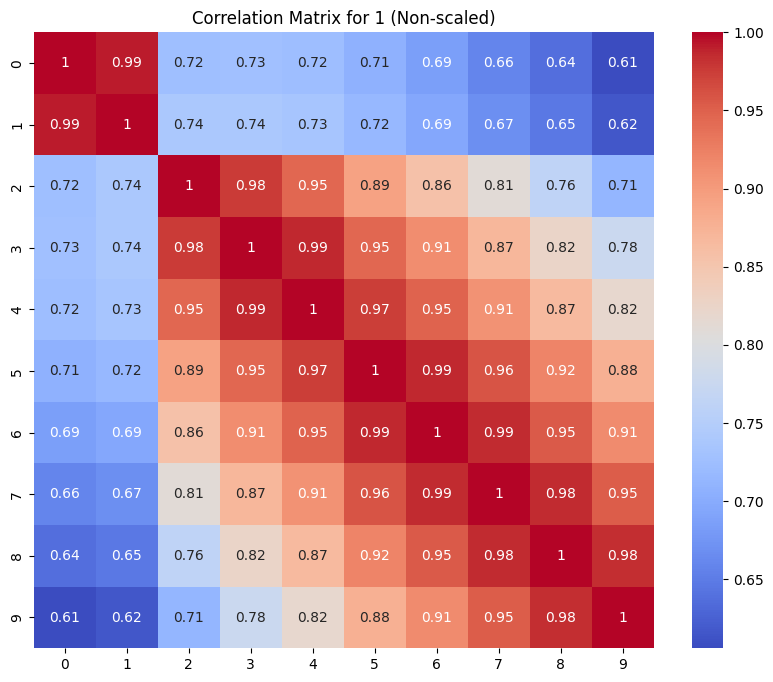

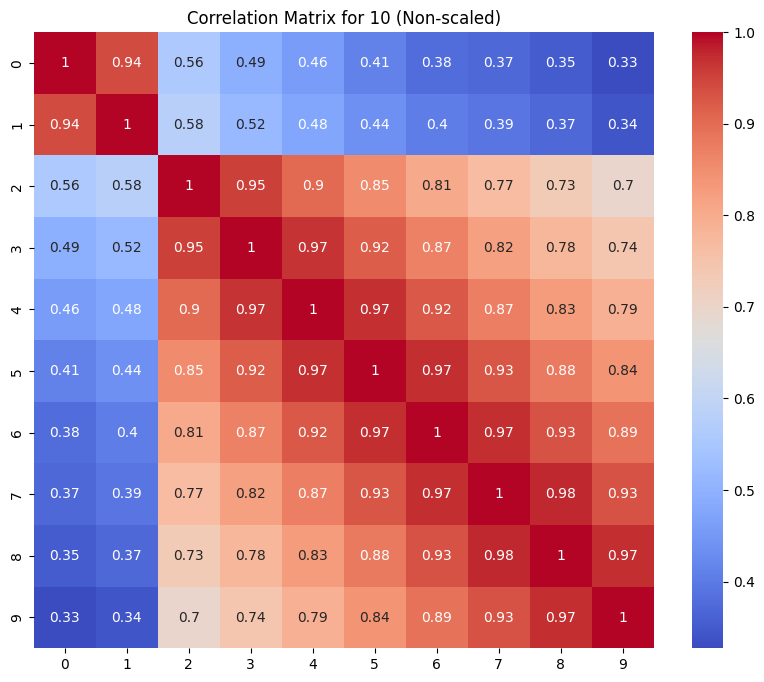

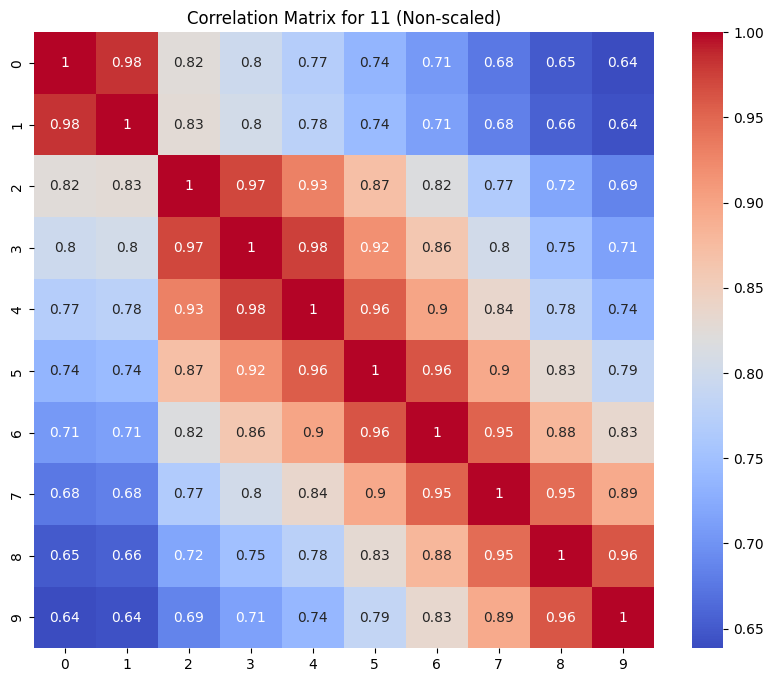

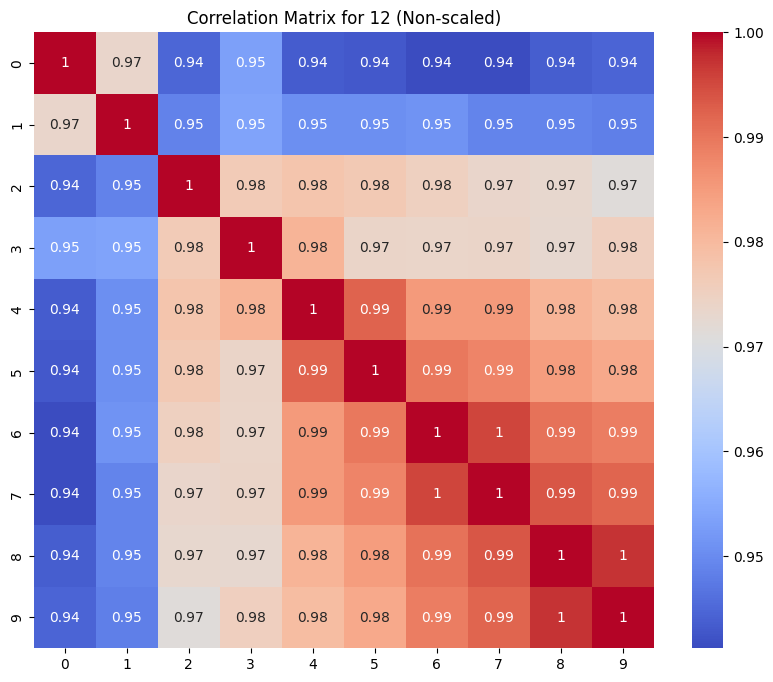

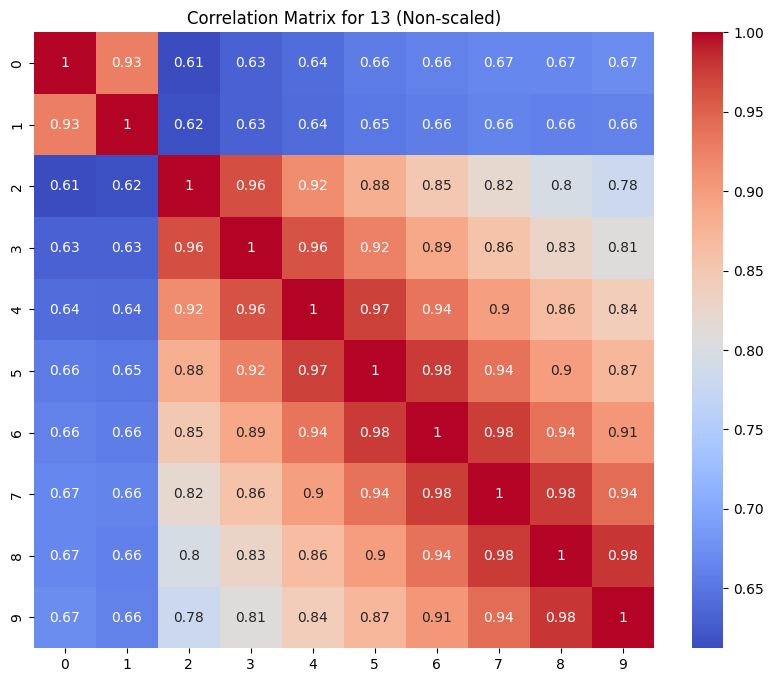

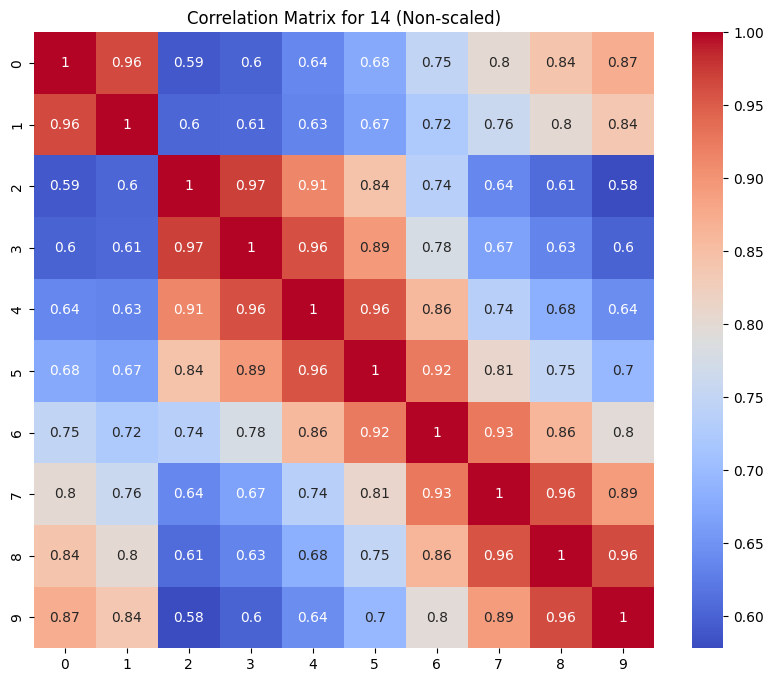

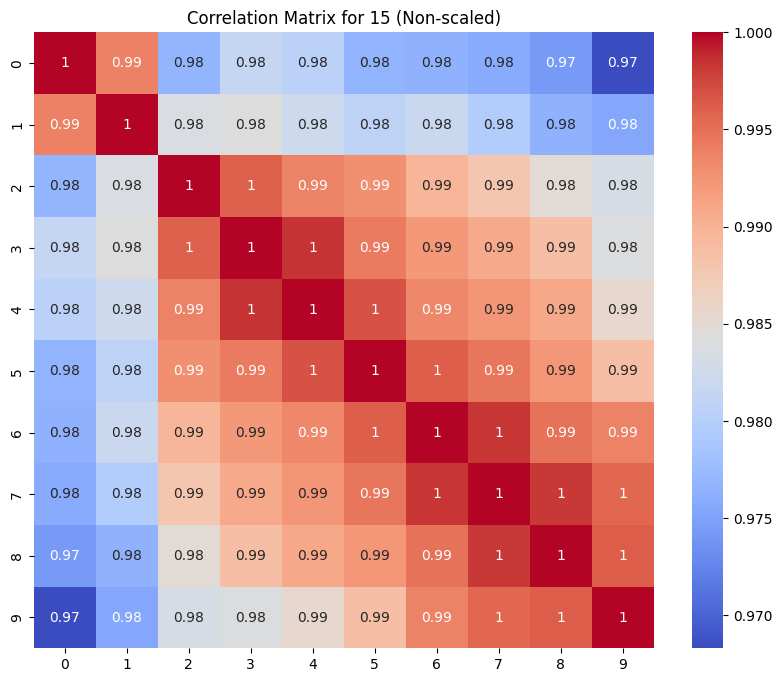

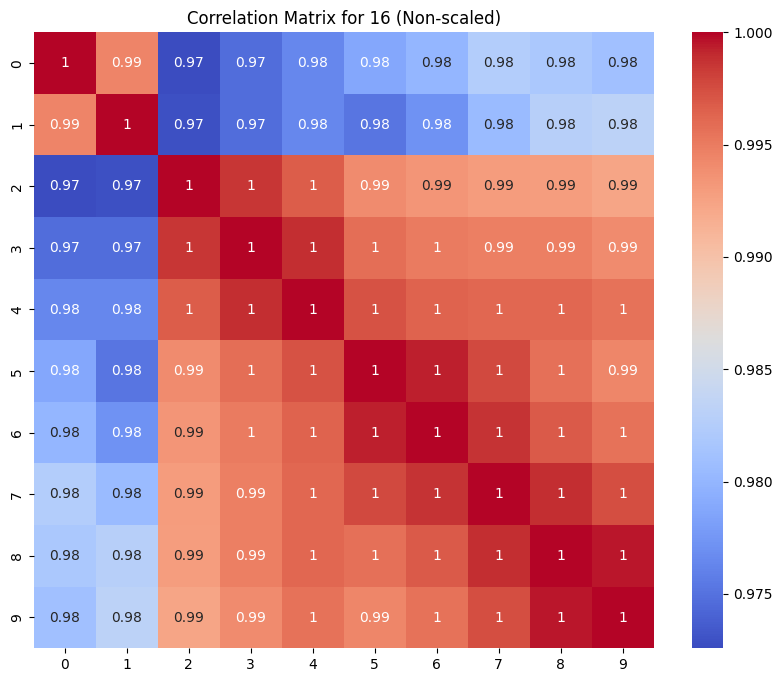

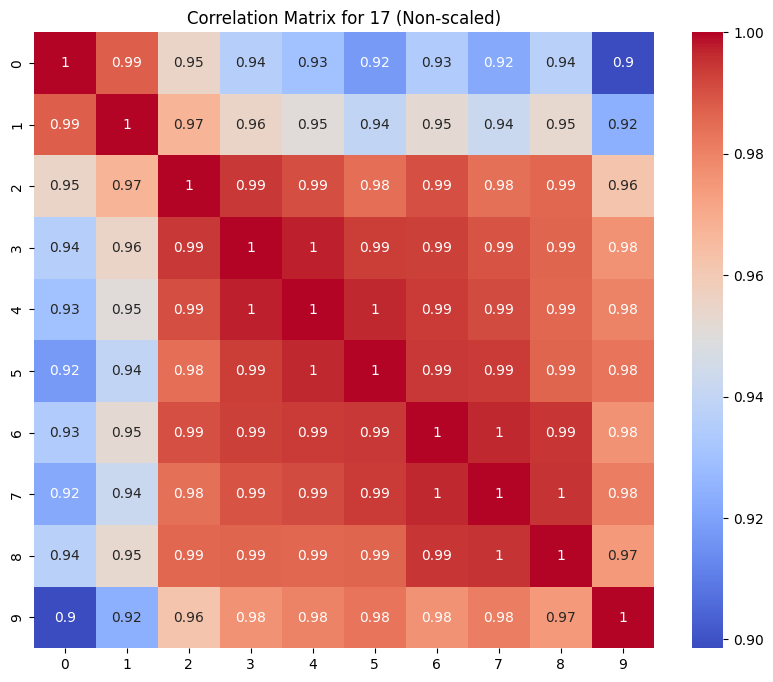

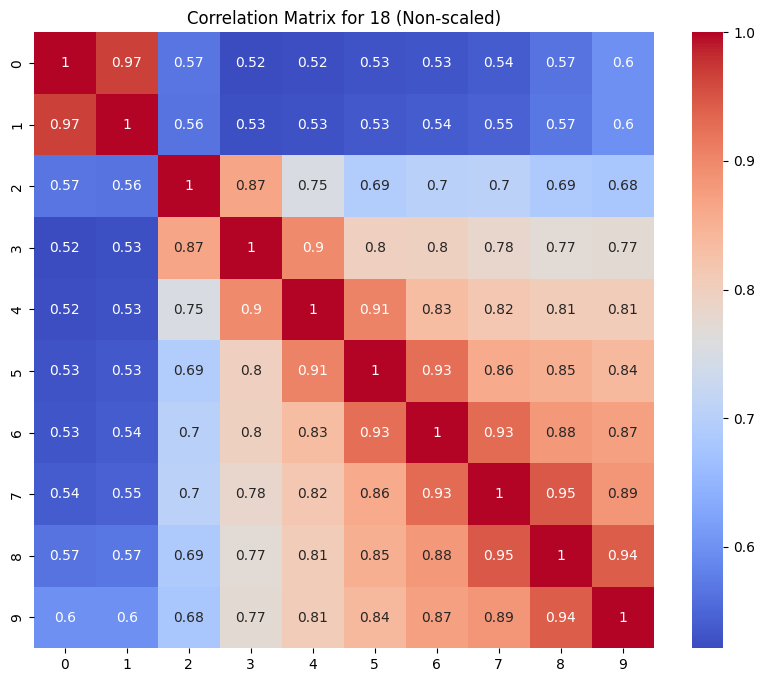

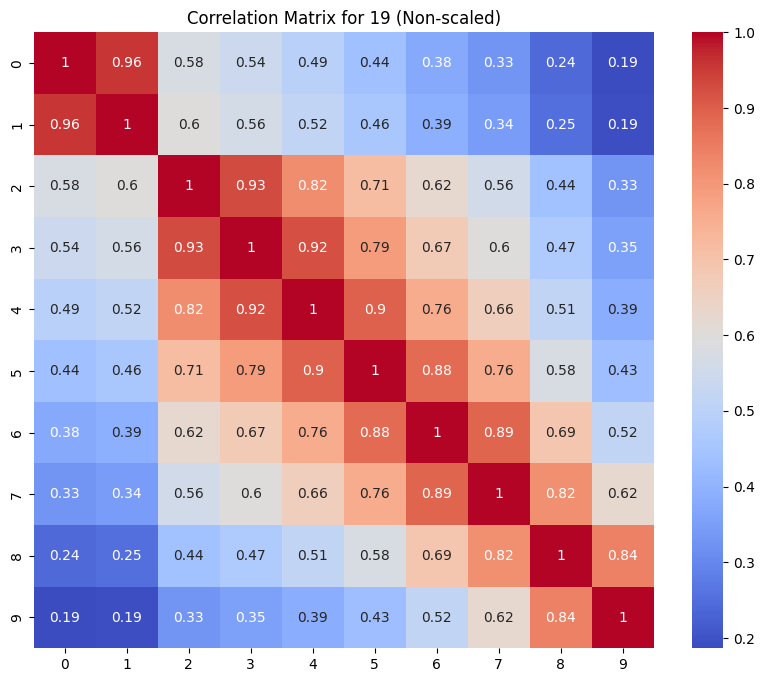

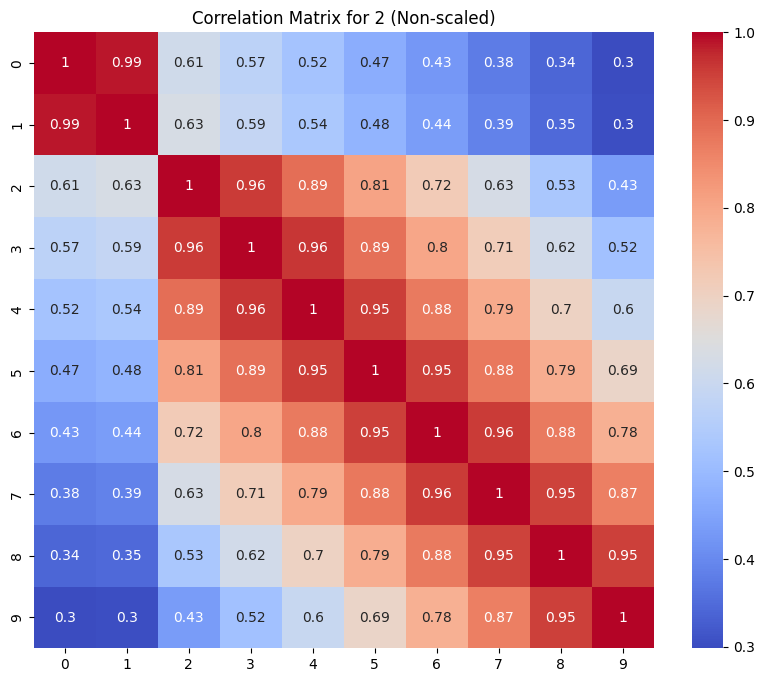

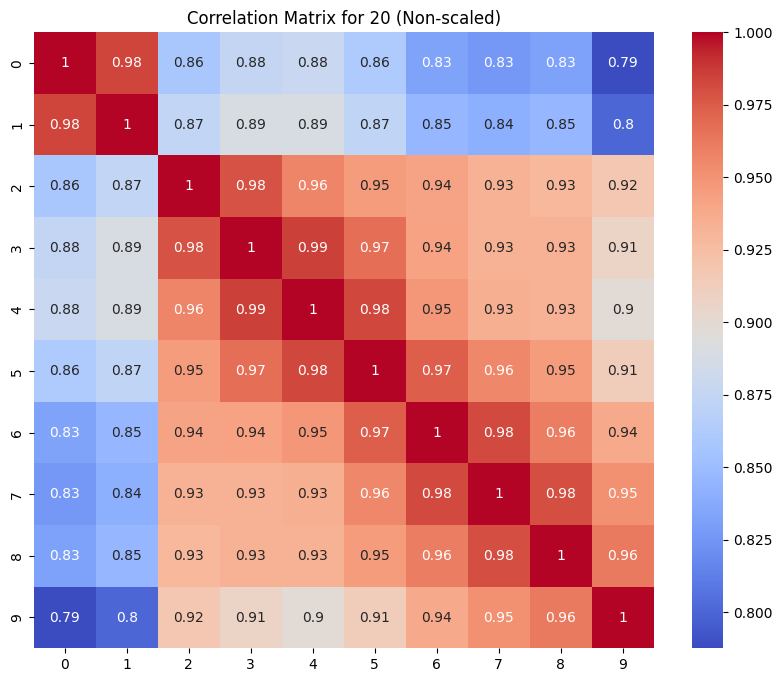

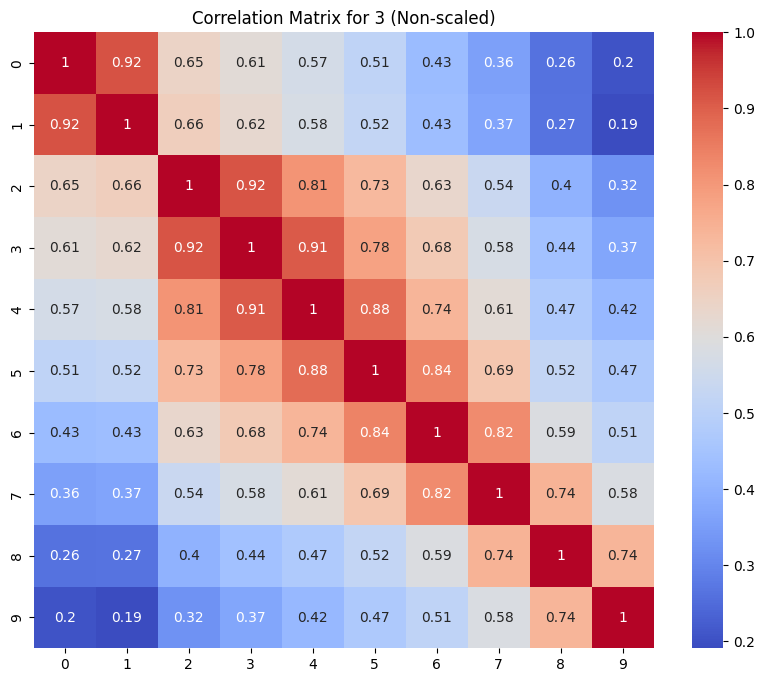

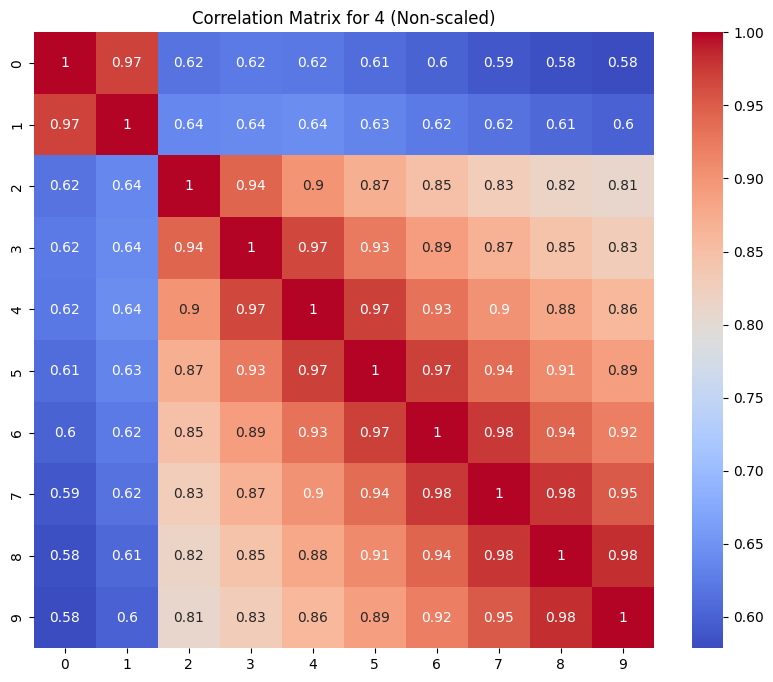

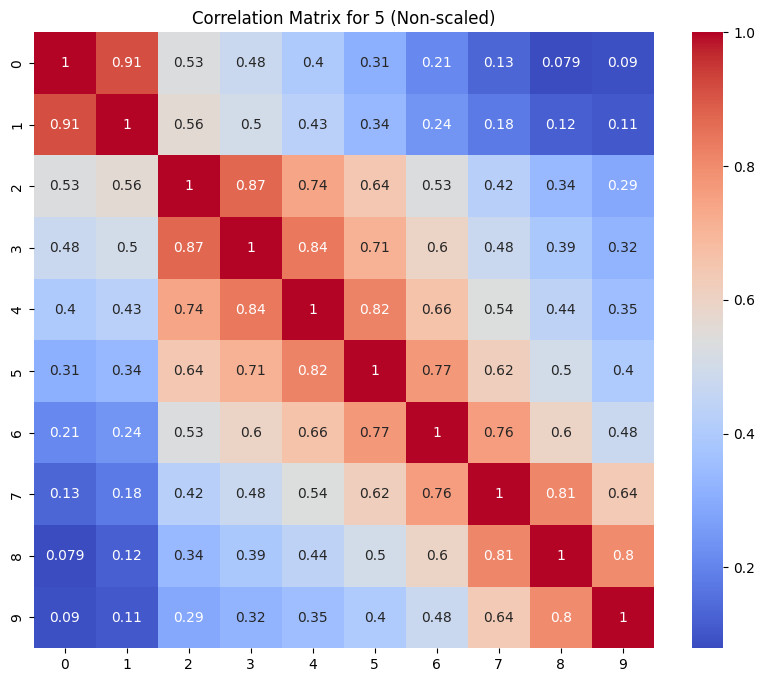

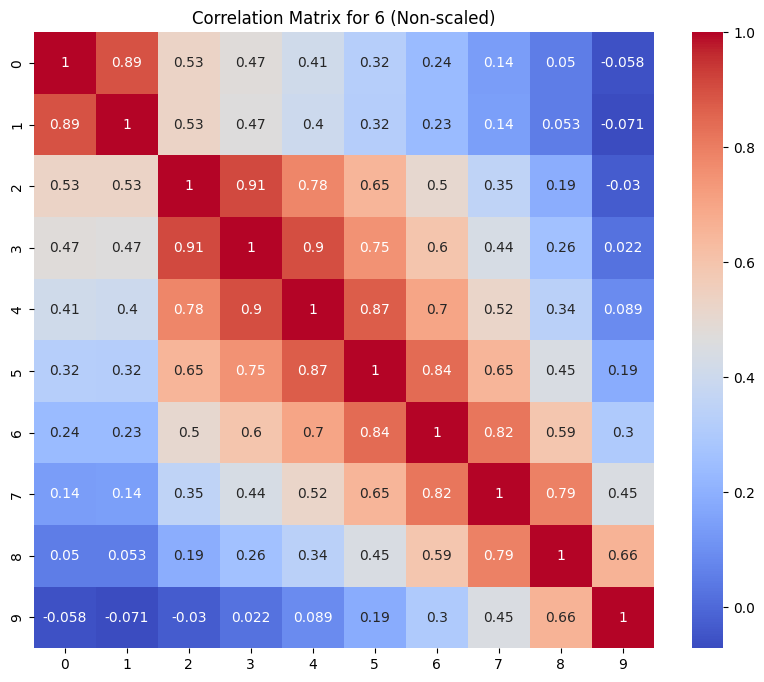

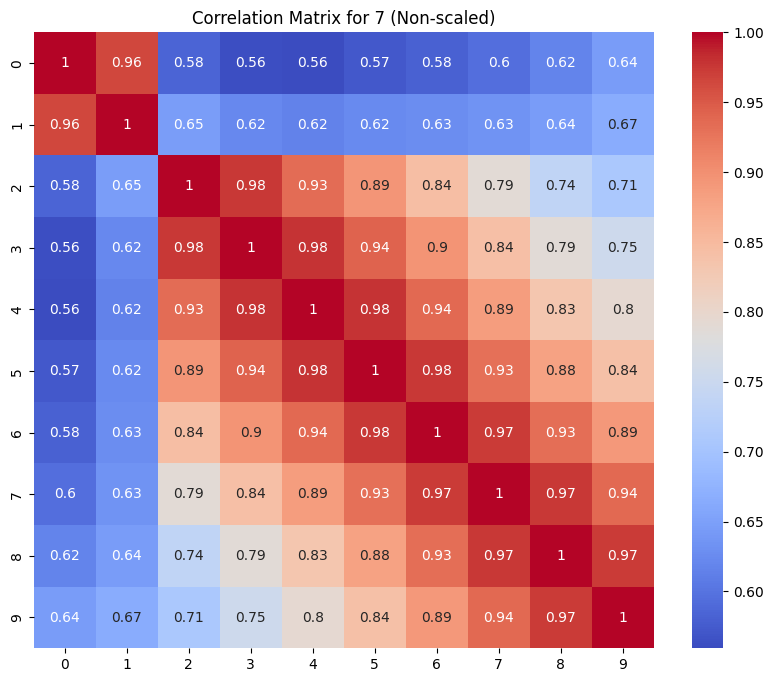

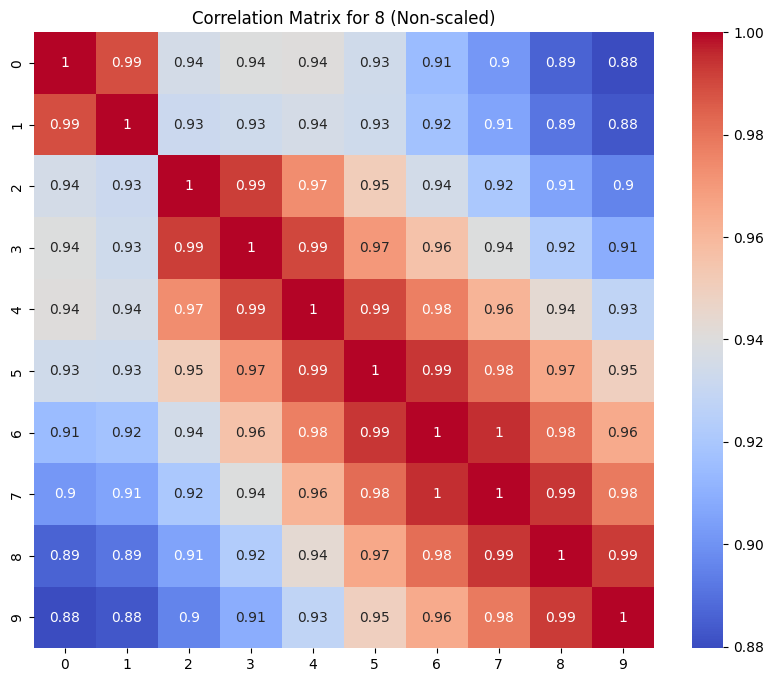

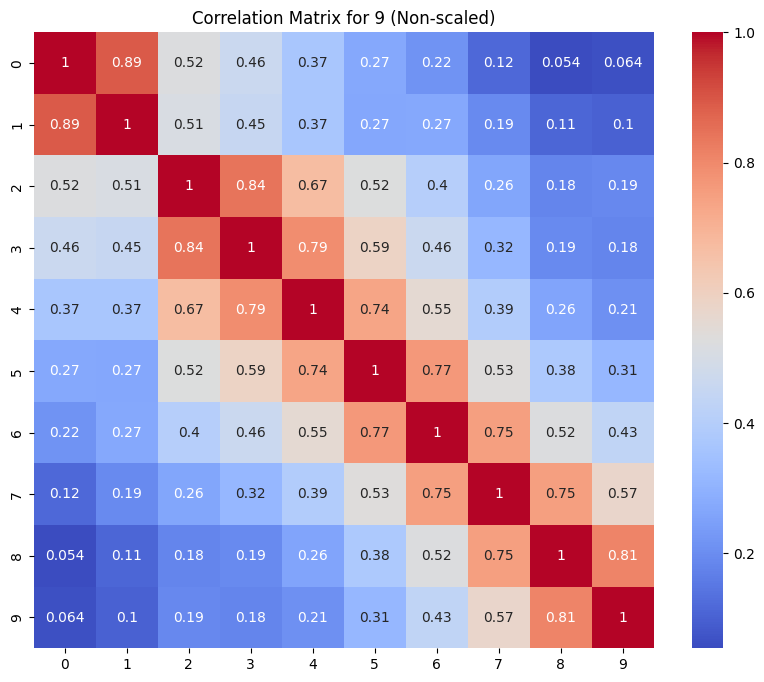

In [11]:
for folder, images in non_scaled_images.items():
    # Take first 10 flattened images from each class
    selected_images = np.array(images[:10])
    
    # Compute correlation matrix
    correlation_matrix = np.corrcoef(selected_images)

    # Create a heatmap using seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True)
    plt.title(f"Correlation Matrix for {folder} (Non-scaled)")
    plt.show()

# Correlation Matrix Analysis (Heat Map)

## General Observations

### Diagonal Values
- All diagonal values are 1 (perfect self-correlation)
- Serves as baseline reference point

### Off-Diagonal Values  
- Represent correlations between different images in same class
- Higher values (closer to 1) indicate stronger similarity
- Lower values (closer to 0) indicate weaker similarity

### Color Patterns
- Red regions show high correlation (strong similarity)
- Blue regions show low correlation (weak similarity)

## Class-Specific Analysis

### Strong Correlations (Classes 8, 16, 17)
- Very high correlations across most images 
- Suggests consistent features and patterns
- Minimal variations in shape/orientation

### Moderate Correlations (Classes 6, 7, 9)
- Mix of moderate correlation values
- Some shared features with notable differences
- Variations in pose/orientation/noise

### Weak Correlations (Classes 3, 5, 19) 
- Lower overall correlations
- Greater diversity within class
- More complex feature variations

## Implications

### Dataset Characteristics
- Classes with high correlations have consistent patterns
- Classes with low correlations show more variability
- Helps identify complexity of different classes

### Analysis Recommendations
- High correlation classes: Simpler dimensionality reduction (e.g. PCA)
- Low correlation classes: Advanced techniques needed (t-SNE/UMAP)
- Correlation patterns inform model selection

### Classification Considerations  
- Strongly correlated classes likely easier to classify
- Weakly correlated classes need more robust models
- Class-specific preprocessing may be beneficial

In [12]:
'''''''''
from sklearn.decomposition import PCA

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)  # Exclude label column

# Convert to DataFrame
df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["Label"] = labels

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Label", palette="viridis", alpha=0.7)
plt.title("PCA Bi-Plot of COIL-20 Images")
plt.show()

'''''''''

'\nfrom sklearn.decomposition import PCA\n\n# Reduce dimensions to 2D for visualization\npca = PCA(n_components=2)\npca_result = pca.fit_transform(df)  # Exclude label column\n\n# Convert to DataFrame\ndf_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])\ndf_pca["Label"] = labels\n\n# Scatter Plot\nplt.figure(figsize=(8,6))\nsns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Label", palette="viridis", alpha=0.7)\nplt.title("PCA Bi-Plot of COIL-20 Images")\nplt.show()\n\n'

In [13]:
flattend_imags_cnn = {}
for folder in images_mnist:
    images_cp = []
    for i in range(len(images_mnist[folder])):
        # Convert to grayscale and flatten the image
        images_cp.append(np.array(Image.fromarray(images_mnist[folder][i]).resize((64,64)).convert('')).flatten())
    flattend_imags_cnn[folder] = np.array(images_cp)


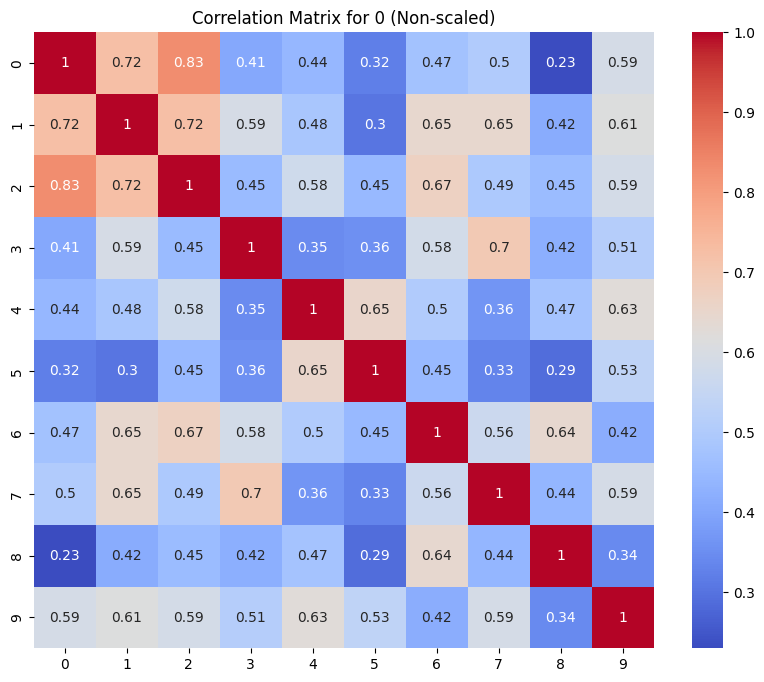

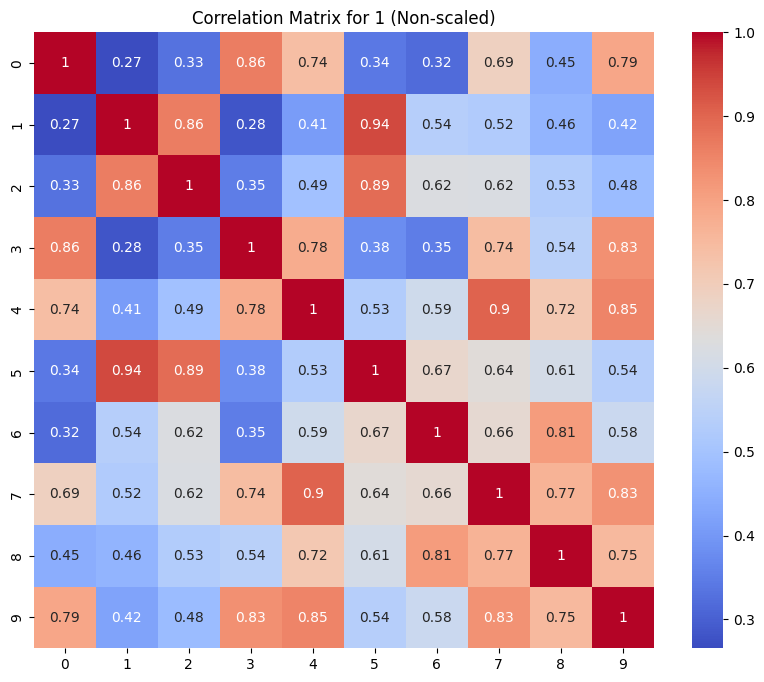

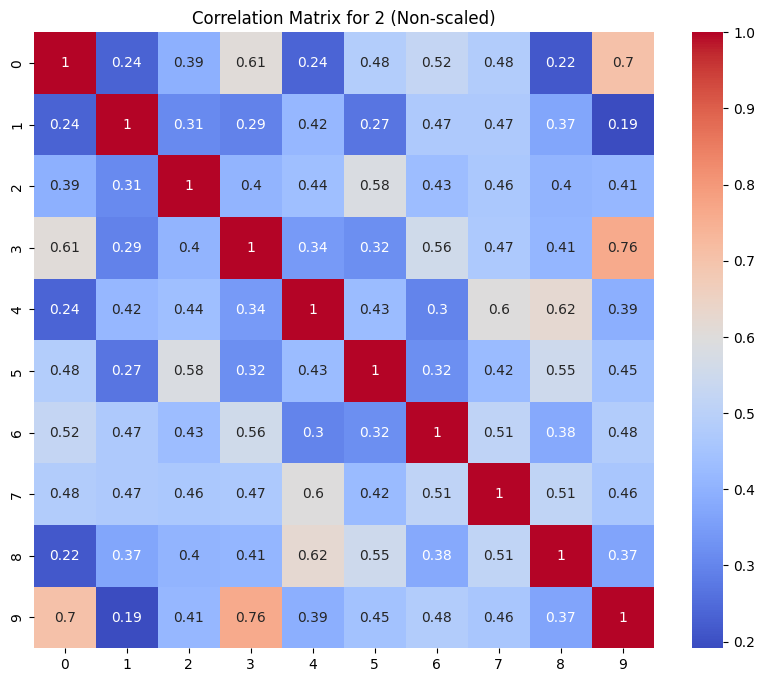

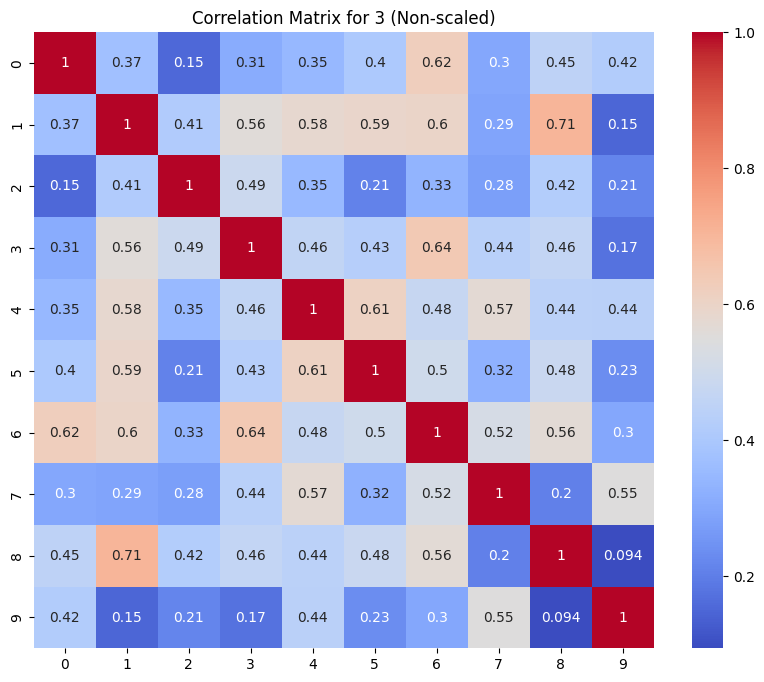

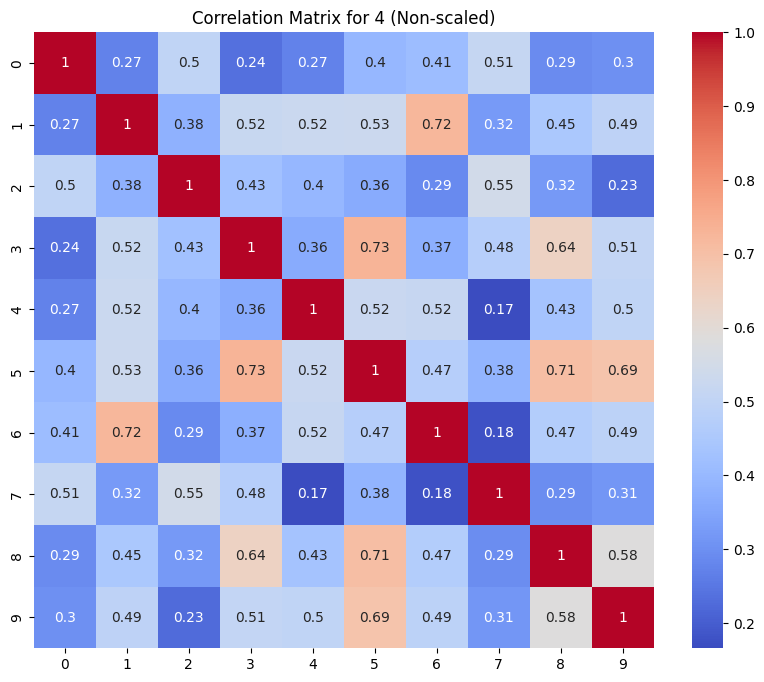

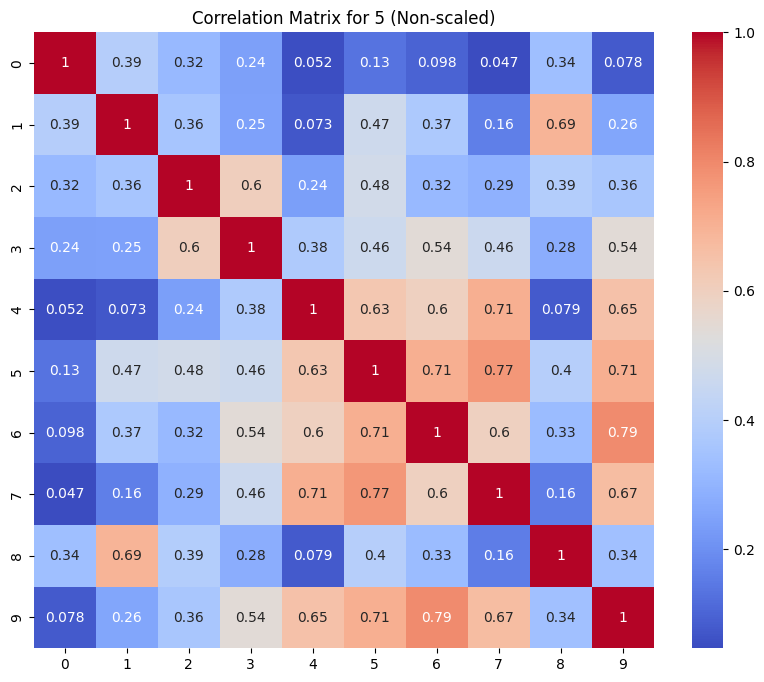

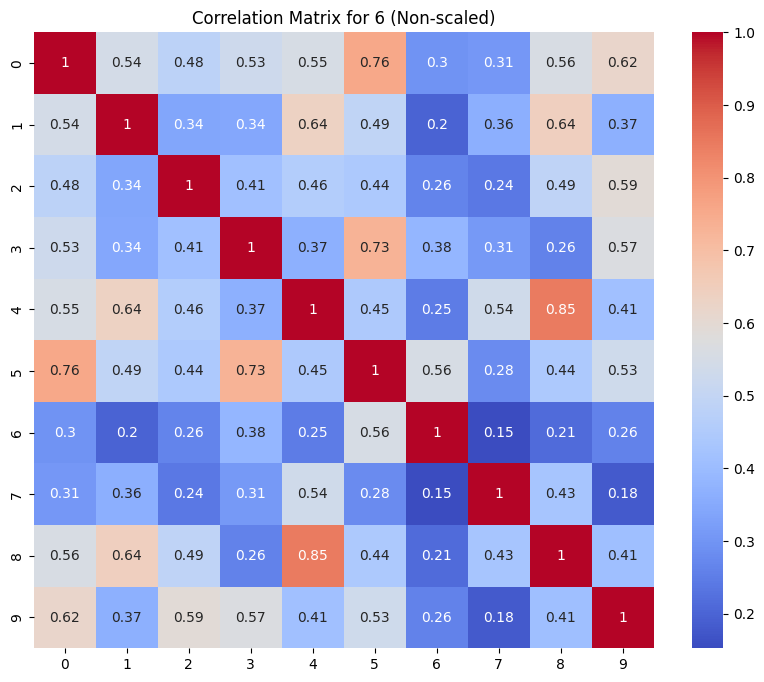

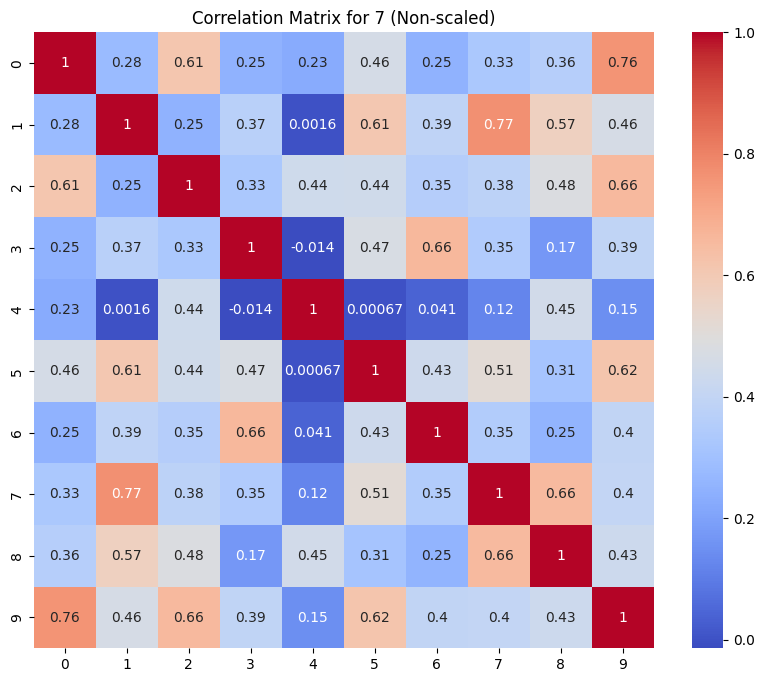

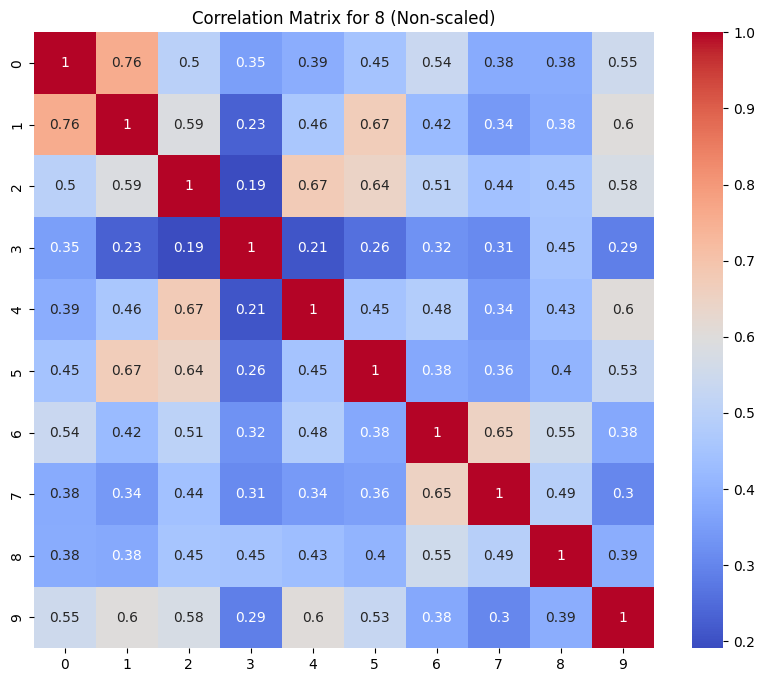

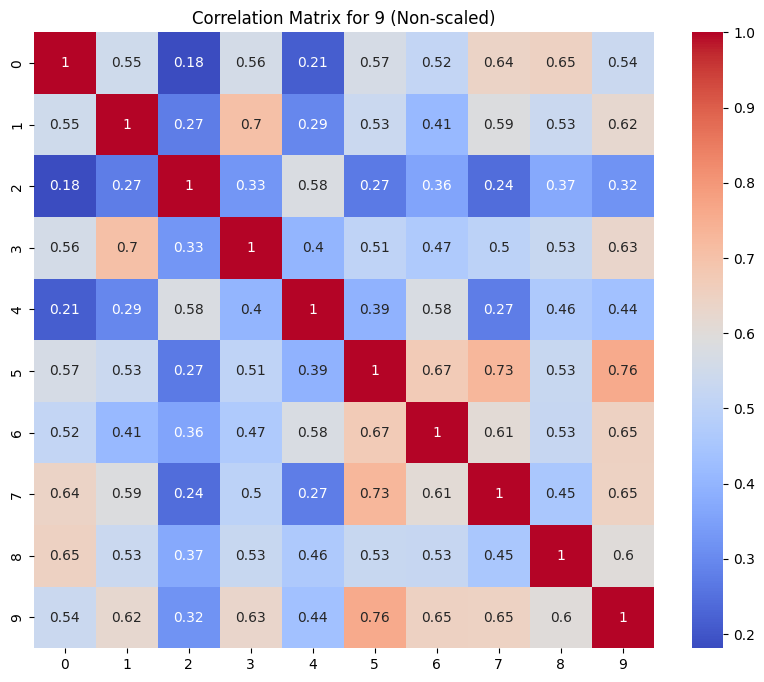

In [14]:
for folder, images in flattend_imags_cnn.items():
    # Take first 10 flattened images from each class
    selected_images = np.array(images[:10])
    
    # Compute correlation matrix
    correlation_matrix = np.corrcoef(selected_images)

    # Create a heatmap using seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True)
    plt.title(f"Correlation Matrix for {folder} (Non-scaled)")
    plt.show()

### **General Observations**
1. **Diagonal Values**:
   - All diagonal values are `1`, representing perfect self-correlation for each image.
   - This is expected and serves as a baseline for comparison.

2. **Off-Diagonal Values**:
   - These represent the correlation between different images within the same class.
   - Higher values (closer to `1`) indicate stronger similarity, while lower values (closer to `0`) indicate weaker similarity or greater variability.

3. **Color Coding**:
   - Red regions indicate high correlation (strong similarity).
   - Blue regions indicate low correlation (weak similarity).

---

### **Class-Specific Observations**
1. **Class 9**:
   - Moderate correlations with some variability.
   - Indicates shared features but also some diversity in the images.

2. **Class 8**:
   - Lower correlations compared to other classes.
   - Suggests significant variability in the images, possibly due to noise, distortions, or diverse patterns.

3. **Class 7**:
   - Very low correlations, with many blue regions.
   - Indicates high intra-class variability, making this class more challenging to analyze or classify.

4. **Class 6**:
   - Moderate correlations with some high values.
   - Suggests a mix of consistent features and variability.

5. **Class 5**:
   - Low correlations overall, with scattered high values.
   - Indicates significant diversity in the images, possibly due to complex patterns or noise.

6. **Class 4**:
   - Moderate correlations with some variability.
   - Indicates shared features but also some differences between images.

7. **Class 3**:
   - Low correlations overall, with scattered high values.
   - Suggests significant intra-class diversity, making this class more complex.

8. **Class 2**:
   - Moderate correlations with some variability.
   - Indicates shared features but also some differences between images.

9. **Class 1**:
   - Moderate to high correlations, with some variability.
   - Suggests more consistent patterns compared to other classes.

10. **Class 0**:
    - Moderate correlations with some variability.
    - Indicates shared features but also some differences between images.

---

### **Dataset Characteristics**
1. **Consistency Across Classes**:
   - Classes like **1**, **6**, and **9** show moderate correlations, indicating some consistency in patterns.
   - Classes like **7**, **5**, and **3** show lower correlations, indicating higher intra-class variability.

2. **Potential Challenges**:
   - Classes with lower correlations (e.g., **7**, **5**, **3**) may be harder to classify due to greater diversity in their patterns.
   - These classes may require more robust feature extraction or preprocessing techniques.

---

### **Implications for Analysis**
1. **Dimensionality Reduction**:
   - Classes with higher correlations (e.g., **1**, **6**) may benefit from simpler dimensionality reduction techniques like PCA.
   - Classes with lower correlations (e.g., **7**, **5**) may require advanced techniques like t-SNE or UMAP to capture the variability.

2. **Clustering and Classification**:
   - Highly correlated classes are likely easier to cluster or classify.
   - Classes with lower correlations may require more sophisticated models or preprocessing to achieve good performance.

---

### **Conclusion**
The correlation matrices highlight the intra-class similarity and variability for each class. These insights can guide the choice of preprocessing, dimensionality reduction, and classification techniques to optimize performance for each class.

In [15]:
# Standardize MNIST images
for folder in flattend_imags_cnn:
    flattend_imags_cnn[folder] = scaler.fit_transform(flattend_imags_cnn[folder])


In [16]:
from sklearn.decomposition import PCA

images_cnn = []
labels = []
for folder , images in flattend_imags_cnn.items():
    for image in flattend_imags_cnn[folder] : 
        images_cnn.append(image)
    labels.extend([folder] * len(images))  # Store corresponding labels# Reduce dimensionality for visualization

images_cnn = np.vstack(images_cnn) 
scaled_images = scaler.fit_transform(images_cnn)

# Apply PCA
pca = PCA(n_components=10)  # Reduce to 10 components
data_pca = pca.fit_transform(scaled_images)

# Convert results into a Pandas DataFrame with labels
df_pca = pd.DataFrame(data_pca, columns=[f'PC{i+1}' for i in range(10)])
labels = np.array([int(label) for label in labels])
df_pca["label"] = labels  # Keep labels for tracking

# Display first few rows
print(df_pca.head())

         PC1        PC2        PC3        PC4        PC5        PC6  \
0  53.001471  -9.257026  -1.283207 -21.249169 -13.485379  16.688054   
1  -9.152770  -9.111648  -9.283983   8.498637   1.574689  27.410705   
2  32.512500  34.362095 -37.119180  -4.429784  21.082191   8.420248   
3 -36.004640 -14.558072   1.869787 -19.874043  -7.551726  -8.647227   
4 -23.094468  28.491293  28.764494  22.144720  -9.237826  42.406115   

         PC7        PC8        PC9       PC10  label  
0  -2.575203   7.345349  25.339523  -4.793396      0  
1  12.727696 -26.651906  19.942731  -2.991527      0  
2 -11.261446 -13.636935  14.306465  13.101997      0  
3   4.202117  -4.331917  -2.463814  -6.485024      0  
4 -30.450975   3.750513 -36.378766 -23.830099      0  


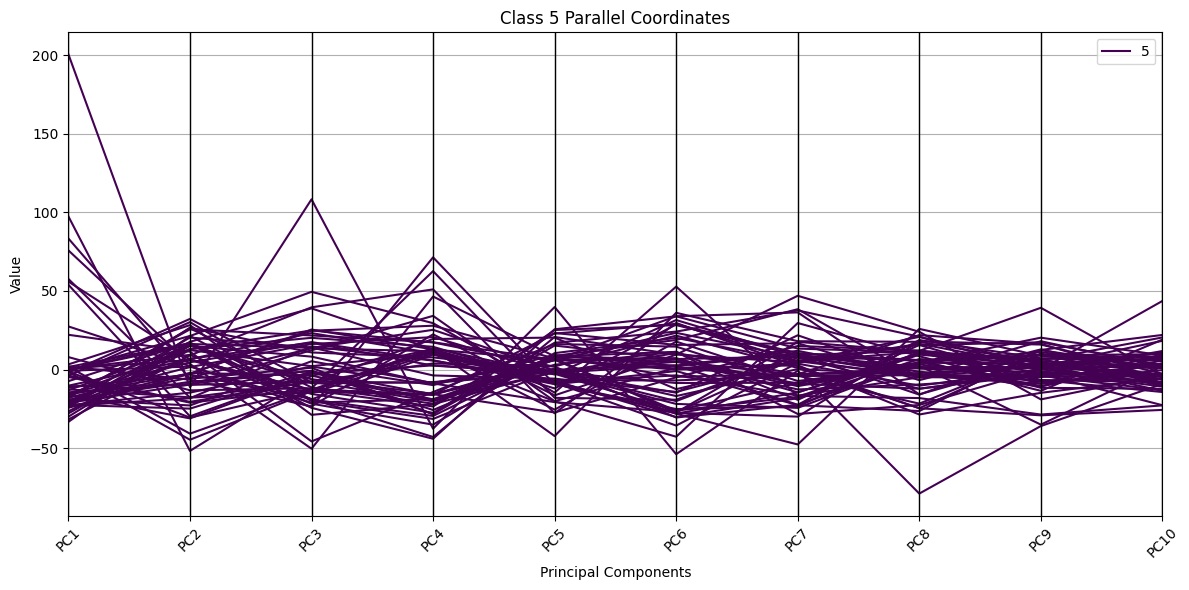

In [17]:
# Create a parallel coordinates plot for class 5
from pandas.plotting import parallel_coordinates
class_data = df_pca[df_pca['label'] == 5].copy()
plt.figure(figsize=(12, 6))
parallel_coordinates(class_data, 'label', colormap='viridis')
plt.title('Class 5 Parallel Coordinates')
plt.xlabel('Principal Components')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Parallel Coordinates Analysis - Class 5

## Data Distribution Pattern

The parallel coordinate visualization for Class 5 images shows:

- Values clustered around 0-30 range across dimensions
- Limited spread and variation between samples
- Consistent pattern suggesting similar image features

## Key Takeaways

- Low variance between images in this class
- Relatively compact representation in feature space 
- Good potential for classification due to consistent patterns

In [18]:
pca = PCA(n_components=2)  # Reduce to 10 components

pca_2 = pca.fit_transform(scaled_images)

In [19]:
"""df_pca_2 = pd.DataFrame(pca_2 , columns=[f'PC{i+1}' for i in range(2)])
df_pca_2['label'] = labels

sns.scatterplot(x = df_pca_2['PC1'] ,y =  df_pca_2['PC2'] , hue = df_pca_2["label"])
"""

'df_pca_2 = pd.DataFrame(pca_2 , columns=[f\'PC{i+1}\' for i in range(2)])\ndf_pca_2[\'label\'] = labels\n\nsns.scatterplot(x = df_pca_2[\'PC1\'] ,y =  df_pca_2[\'PC2\'] , hue = df_pca_2["label"])\n'

In [20]:
pca = PCA(n_components=3)  # Reduce to 10 components

pca_3 = pca.fit_transform(scaled_images)

In [21]:
df_pca_3 = pd.DataFrame(pca_3 , columns=[f'PC{i+1}' for i in range(3)])
df_pca_3['label'] = labels

In [22]:
"""from mpl_toolkits.mplot3d import Axes3D

# Assuming df_pca_3 contains the first 3 principal components and labels
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for PC1, PC2, PC3
scatter = ax.scatter(df_pca_3['PC1'], df_pca_3['PC2'], df_pca_3['PC3'], c=df_pca_3['label'].astype('category').cat.codes, cmap='viridis')

# Adding labels to axes
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Adding a color bar to indicate label mappings
cbar = plt.colorbar(scatter, ax=ax, label='Label')

# Title of the plot
ax.set_title('3D PCA Plot')

# Show the plot
plt.show()
"""

"from mpl_toolkits.mplot3d import Axes3D\n\n# Assuming df_pca_3 contains the first 3 principal components and labels\nfig = plt.figure(figsize=(10, 8))\nax = fig.add_subplot(111, projection='3d')\n\n# Scatter plot for PC1, PC2, PC3\nscatter = ax.scatter(df_pca_3['PC1'], df_pca_3['PC2'], df_pca_3['PC3'], c=df_pca_3['label'].astype('category').cat.codes, cmap='viridis')\n\n# Adding labels to axes\nax.set_xlabel('Principal Component 1')\nax.set_ylabel('Principal Component 2')\nax.set_zlabel('Principal Component 3')\n\n# Adding a color bar to indicate label mappings\ncbar = plt.colorbar(scatter, ax=ax, label='Label')\n\n# Title of the plot\nax.set_title('3D PCA Plot')\n\n# Show the plot\nplt.show()\n"

In [23]:
pca_2_coil = PCA(n_components=2)
scaled_images_coil  = []
labels_coil = []
for folder in flattend_imags : 
    for image in flattend_imags[folder] : 
        scaled_images_coil.append(image)
    labels_coil.extend([folder]*len(flattend_imags[folder]))
scaled_images_coil = scaler.fit_transform(np.vstack(scaled_images_coil))
labels_coil = np.array([int(label) for label in labels_coil])

pca_2_coil = pca_2_coil.fit_transform(scaled_images_coil)

In [24]:
"""df_pca2_coil  = pd.DataFrame(pca_2_coil , columns = [f"PC{i+1}" for i in range(2)])
df_pca2_coil['label'] = labels_coil
sns.scatterplot(x = df_pca2_coil['PC1'] , y = df_pca2_coil['PC2'] , hue = df_pca2_coil['label'] )"""

'df_pca2_coil  = pd.DataFrame(pca_2_coil , columns = [f"PC{i+1}" for i in range(2)])\ndf_pca2_coil[\'label\'] = labels_coil\nsns.scatterplot(x = df_pca2_coil[\'PC1\'] , y = df_pca2_coil[\'PC2\'] , hue = df_pca2_coil[\'label\'] )'

In [25]:
pca = PCA(n_components=10)
pca_10_coil = pca.fit_transform(scaled_images_coil)[:, :10]

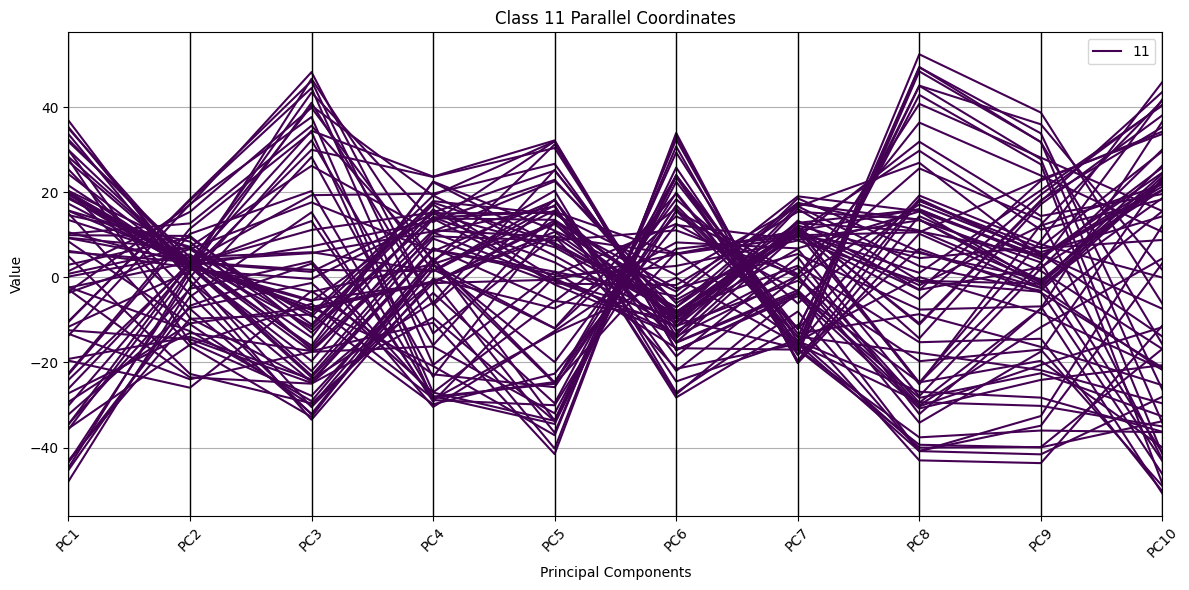

In [26]:
# Create DataFrame with PCA components and labels
df_pca_coil = pd.DataFrame(pca_10_coil, columns=[f'PC{i+1}' for i in range(10)])
df_pca_coil['label'] = labels_coil

# Filter data for class 11 only
class_data = df_pca_coil[df_pca_coil['label'] == 11].copy()

# Create parallel coordinates plot for class 11
plt.figure(figsize=(12, 6))
parallel_coordinates(class_data, 'label', colormap='viridis')
plt.title('Class 11 Parallel Coordinates')
plt.xlabel('Principal Components')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Class 11 Analysis

## Pattern Variations
The parallel coordinates plot for Class 11 reveals high variability across principal components, indicating:

- Large amplitude oscillations between different PCs
- Inconsistent patterns across samples
- High intra-class variability

These extreme variations suggest significant differences in visual characteristics between images within Class 11, likely due to:

- Different viewing angles
- Changes in lighting/shadows  
- Object pose variations
- Other transformations

## Key Observations
1. **Principal Component Values**
    - Wide range of values across PCs 
    - No clear dominant pattern
    - High variance between samples

2. **Pattern Characteristics**  
    - Irregular oscillations
    - Multiple distinct clusters
    - Low correlation between successive PCs

3. **Implications**
    - Complex underlying structure
    - Challenging classification target
    - May need robust feature extraction

In [27]:
"""""""""""
from sklearn.manifold import TSNE
import umap
import nxcurve
0

# Apply UMAP (2D & 3D)
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(scaled_images)
umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(scaled_images)
"""""""""


'""\nfrom sklearn.manifold import TSNE\nimport umap\nimport nxcurve\n0\n\n# Apply UMAP (2D & 3D)\numap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(scaled_images)\numap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(scaled_images)\n'

In [28]:
from sklearn.manifold import TSNE
"""
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(scaled_images)
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42).fit_transform(scaled_images)
"""


'\ntsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(scaled_images)\ntsne_3d = TSNE(n_components=3, perplexity=30, random_state=42).fit_transform(scaled_images)\n'

In [29]:
# Create figure with two subplots for MNIST data
"""""
fig = plt.figure(figsize=(15, 6))

# 2D t-SNE visualization
plt.subplot(121)
scatter = plt.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=[int(label) for label in labels], 
                     cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Classes')
plt.title('2D t-SNE Visualization')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 3D t-SNE visualization
ax = fig.add_subplot(122, projection='3d')
scatter = ax.scatter(tsne_3d[:, 0], tsne_3d[:, 1], tsne_3d[:, 2],
                    c=[int(label) for label in labels], cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Classes')
plt.title('3D t-SNE Visualization')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')

plt.tight_layout()
plt.show()
"""

'""\nfig = plt.figure(figsize=(15, 6))\n\n# 2D t-SNE visualization\nplt.subplot(121)\nscatter = plt.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=[int(label) for label in labels], \n                     cmap=\'tab20\', alpha=0.7)\nplt.colorbar(scatter, label=\'Classes\')\nplt.title(\'2D t-SNE Visualization\')\nplt.xlabel(\'t-SNE 1\')\nplt.ylabel(\'t-SNE 2\')\n\n# 3D t-SNE visualization\nax = fig.add_subplot(122, projection=\'3d\')\nscatter = ax.scatter(tsne_3d[:, 0], tsne_3d[:, 1], tsne_3d[:, 2],\n                    c=[int(label) for label in labels], cmap=\'tab20\', alpha=0.7)\nplt.colorbar(scatter, label=\'Classes\')\nplt.title(\'3D t-SNE Visualization\')\nax.set_xlabel(\'t-SNE 1\')\nax.set_ylabel(\'t-SNE 2\')\nax.set_zlabel(\'t-SNE 3\')\n\nplt.tight_layout()\nplt.show()\n'

In [30]:
"""
# Apply t-SNE for COIL-20 dataset
tsne_2d_coil = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(scaled_images_coil)
tsne_3d_coil = TSNE(n_components=3, perplexity=30, random_state=42).fit_transform(scaled_images_coil)

# Create figure with two subplots for COIL-20 data
fig = plt.figure(figsize=(15, 6))

# 2D t-SNE visualization
plt.subplot(121)
scatter = plt.scatter(tsne_2d_coil[:, 0], tsne_2d_coil[:, 1], c=[int(label) for label in labels_coil], 
                     cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Classes')
plt.title('2D t-SNE Visualization of COIL-20')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 3D t-SNE visualization
ax = fig.add_subplot(122, projection='3d')
scatter = ax.scatter(tsne_3d_coil[:, 0], tsne_3d_coil[:, 1], tsne_3d_coil[:, 2],
                    c=[int(label) for label in labels_coil], cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Classes')
plt.title('3D t-SNE Visualization of COIL-20')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')

plt.tight_layout()
plt.show()
"""

"\n# Apply t-SNE for COIL-20 dataset\ntsne_2d_coil = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(scaled_images_coil)\ntsne_3d_coil = TSNE(n_components=3, perplexity=30, random_state=42).fit_transform(scaled_images_coil)\n\n# Create figure with two subplots for COIL-20 data\nfig = plt.figure(figsize=(15, 6))\n\n# 2D t-SNE visualization\nplt.subplot(121)\nscatter = plt.scatter(tsne_2d_coil[:, 0], tsne_2d_coil[:, 1], c=[int(label) for label in labels_coil], \n                     cmap='tab20', alpha=0.7)\nplt.colorbar(scatter, label='Classes')\nplt.title('2D t-SNE Visualization of COIL-20')\nplt.xlabel('t-SNE 1')\nplt.ylabel('t-SNE 2')\n\n# 3D t-SNE visualization\nax = fig.add_subplot(122, projection='3d')\nscatter = ax.scatter(tsne_3d_coil[:, 0], tsne_3d_coil[:, 1], tsne_3d_coil[:, 2],\n                    c=[int(label) for label in labels_coil], cmap='tab20', alpha=0.7)\nplt.colorbar(scatter, label='Classes')\nplt.title('3D t-SNE Visualization of COIL-20')\nax.set

c:\Users\USER\anaconda3\envs\git\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\USER\anaconda3\envs\git\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\USER\anaconda3\envs\git\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\USER\anaconda3\envs\git\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\USER\anaconda3\envs\git\lib\subprocess.p

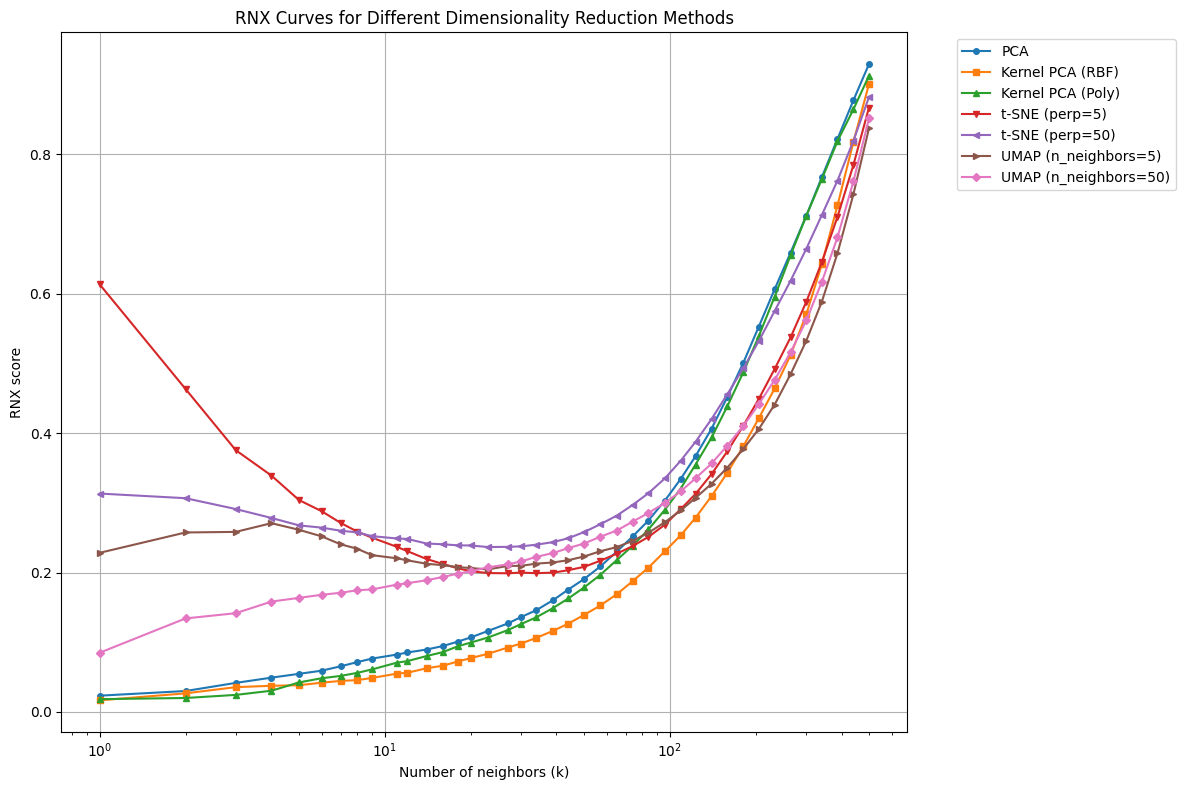

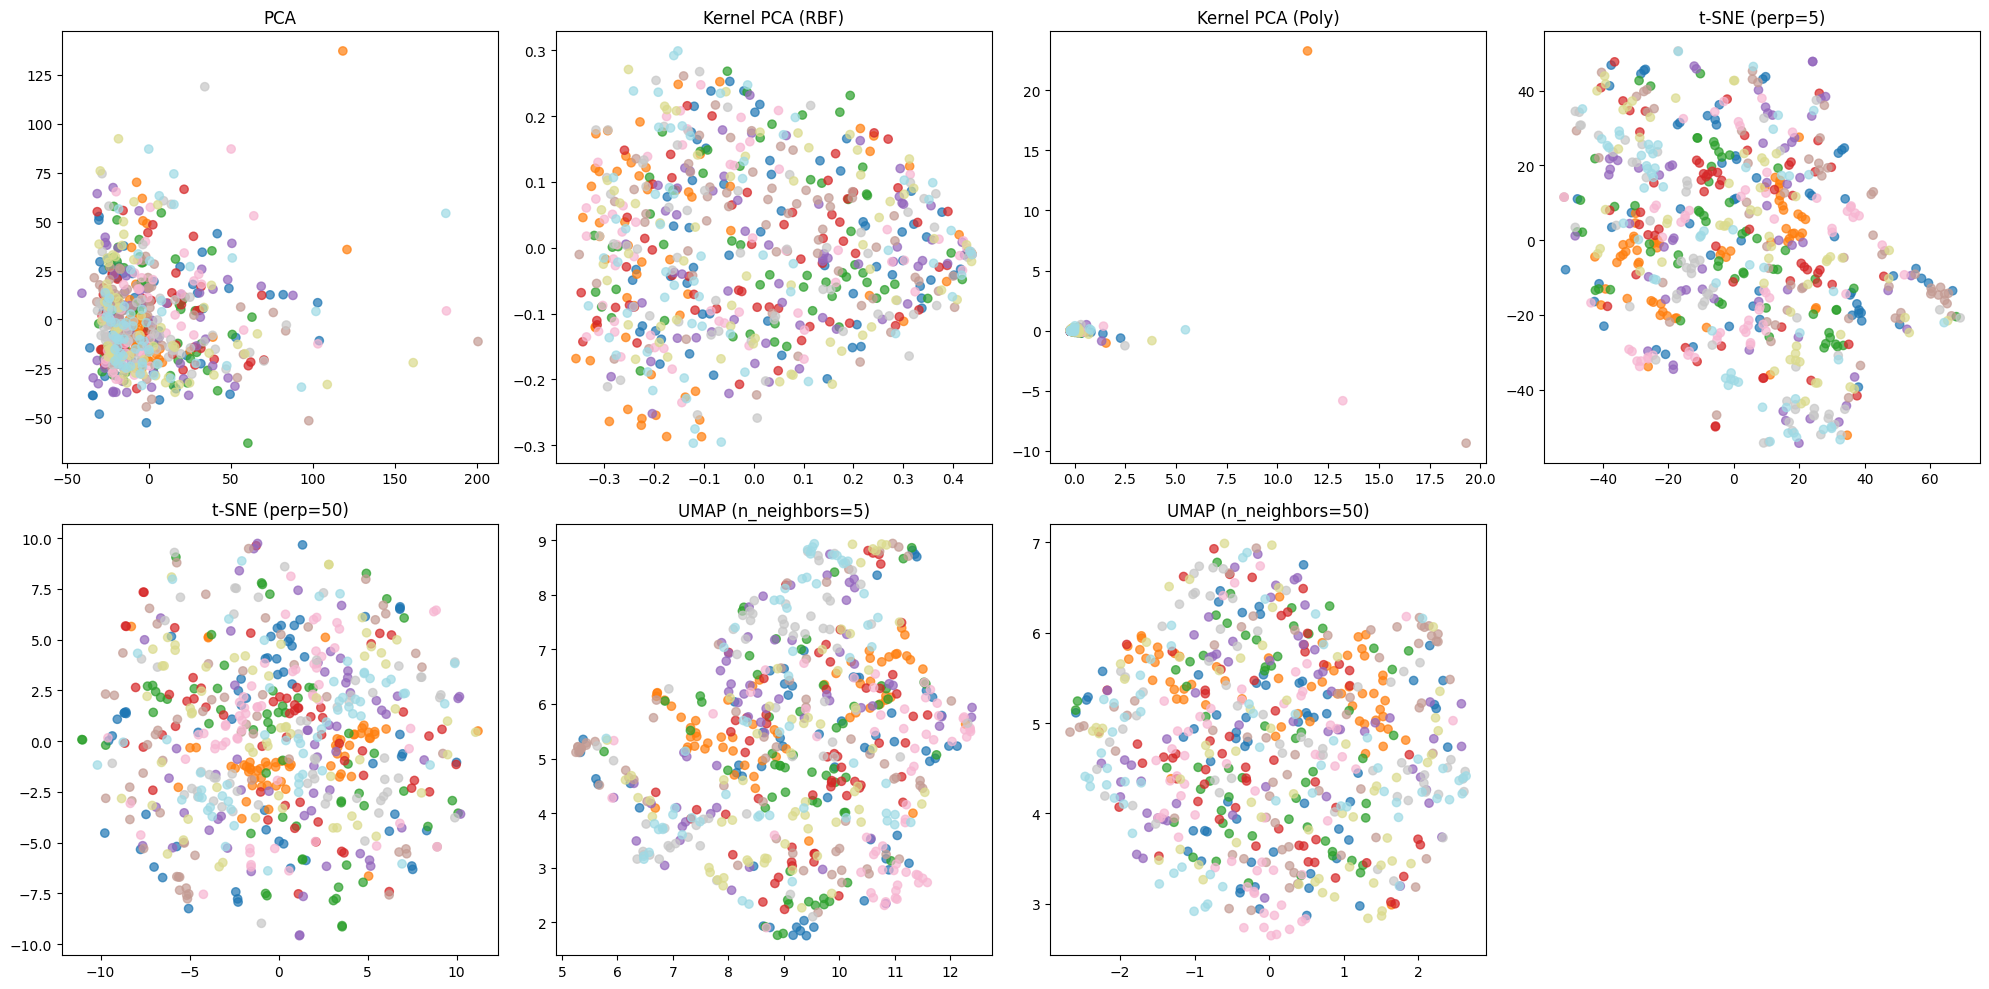

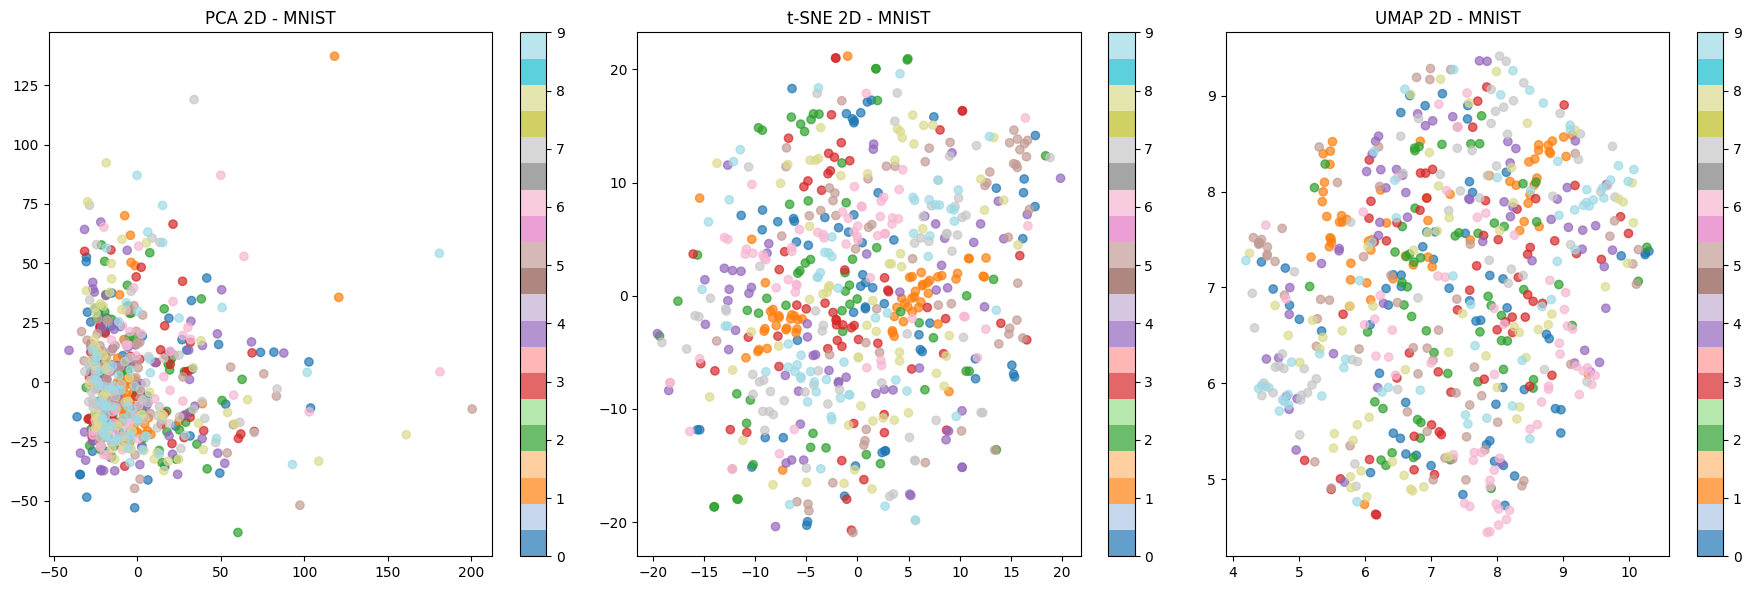

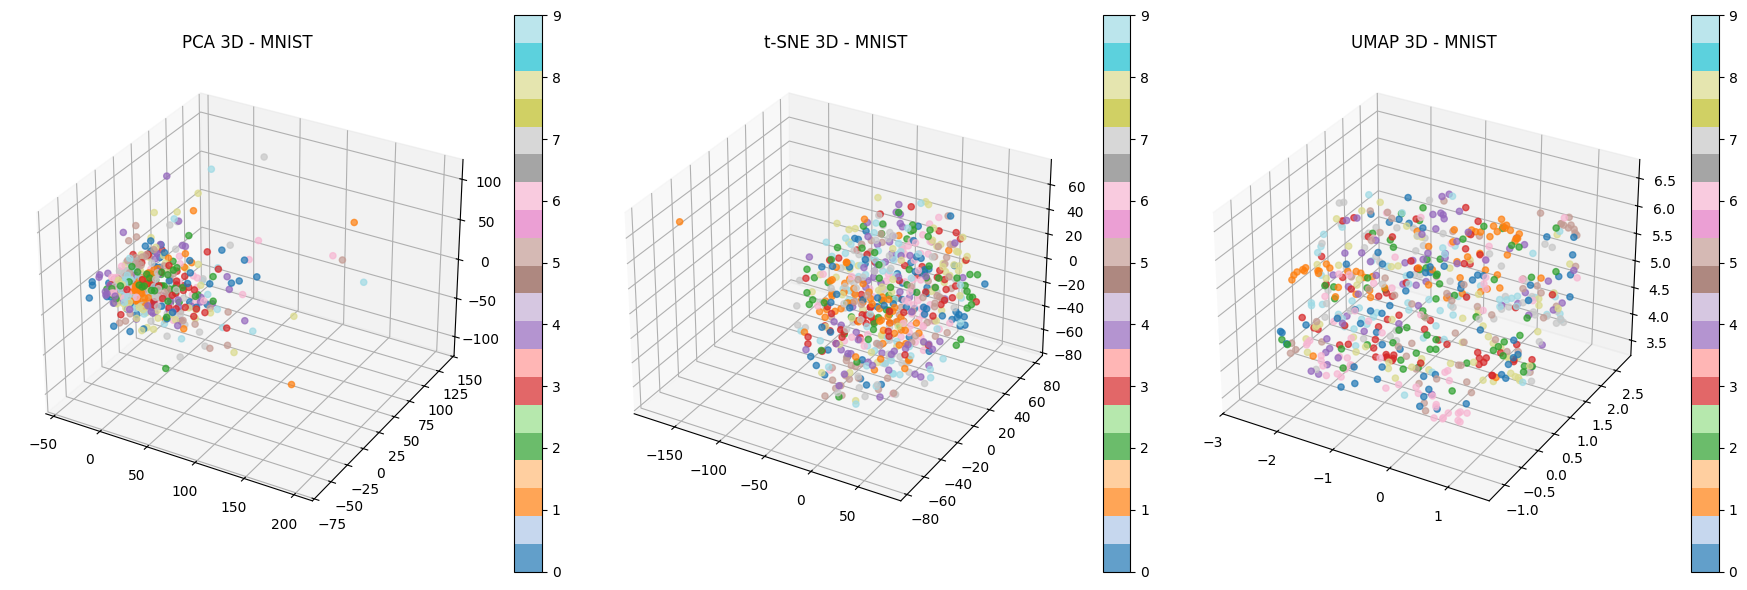

In [31]:
import numpy as np
import umap
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Initialize dimension reduction methods
pca = PCA(random_state=42)
pca_2_mnist = pca.fit_transform(scaled_images)[:, :2]
pca_3_mnist = pca.fit_transform(scaled_images)[:, :3]

tsne_2d_mnist = TSNE(n_components=2, random_state=42).fit_transform(scaled_images)
tsne_3d_mnist = TSNE(n_components=3, random_state=42).fit_transform(scaled_images)

umap_2d_mnist = umap.UMAP(n_components=2, random_state=42)
umap_3d_mnist = umap.UMAP(n_components=3, random_state=42)

# Apply UMAP
umap_2d_mnist_result = umap_2d_mnist.fit_transform(scaled_images)
umap_3d_mnist_result = umap_3d_mnist.fit_transform(scaled_images)

# Define function to compute RNX curves for different k values
def compute_rnx_curves(data_original, data_embedded, k_values):
    """Compute RNX curves for different numbers of neighbors."""
    rnx_values = []
    
    for k in k_values:
        # Fit nearest neighbors for original data
        nn_original = NearestNeighbors(n_neighbors=k+1).fit(data_original)
        distances_original, indices_original = nn_original.kneighbors(data_original)
        
        # Fit nearest neighbors for embedded data
        nn_embedded = NearestNeighbors(n_neighbors=k+1).fit(data_embedded)
        distances_embedded, indices_embedded = nn_embedded.kneighbors(data_embedded)
        
        # Calculate neighborhood preservation
        preserved = 0
        total = 0
        for i in range(len(data_original)):
            original_neighbors = set(indices_original[i][1:])
            embedded_neighbors = set(indices_embedded[i][1:])
            preserved += len(original_neighbors.intersection(embedded_neighbors))
            total += k
            
        rnx = preserved / total
        rnx_values.append(rnx)
    
    return np.array(rnx_values)


# Initialize dimension reduction methods with different parameters
pca = PCA(random_state=42)
kpca_rbf = KernelPCA(n_components=2, kernel='rbf', random_state=42)
kpca_poly = KernelPCA(n_components=2, kernel='poly', degree=3, random_state=42)

tsne_low_perp = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_high_perp = TSNE(n_components=2, perplexity=50, random_state=42)

umap_low_neigh = umap.UMAP(n_components=2, n_neighbors=5, random_state=42)
umap_high_neigh = umap.UMAP(n_components=2, n_neighbors=50, random_state=42)

# Apply dimension reduction
pca_2d = pca.fit_transform(scaled_images)[:, :2]
kpca_rbf_2d = kpca_rbf.fit_transform(scaled_images)
kpca_poly_2d = kpca_poly.fit_transform(scaled_images)
tsne_low_perp_2d = tsne_low_perp.fit_transform(scaled_images)
tsne_high_perp_2d = tsne_high_perp.fit_transform(scaled_images)
umap_low_neigh_2d = umap_low_neigh.fit_transform(scaled_images)
umap_high_neigh_2d = umap_high_neigh.fit_transform(scaled_images)

# Define k values (using existing k_values)
k_values = np.logspace(0, np.log10(500), num=50, dtype=int)
k_values = np.unique(k_values)

# Calculate RNX curves
rnx_pca = compute_rnx_curves(scaled_images, pca_2d, k_values)
rnx_kpca_rbf = compute_rnx_curves(scaled_images, kpca_rbf_2d, k_values)
rnx_kpca_poly = compute_rnx_curves(scaled_images, kpca_poly_2d, k_values)
rnx_tsne_low = compute_rnx_curves(scaled_images, tsne_low_perp_2d, k_values)
rnx_tsne_high = compute_rnx_curves(scaled_images, tsne_high_perp_2d, k_values)
rnx_umap_low = compute_rnx_curves(scaled_images, umap_low_neigh_2d, k_values)
rnx_umap_high = compute_rnx_curves(scaled_images, umap_high_neigh_2d, k_values)

# Plot RNX curves
plt.figure(figsize=(12, 8))
plt.semilogx(k_values, rnx_pca, label='PCA', marker='o', markersize=4)
plt.semilogx(k_values, rnx_kpca_rbf, label='Kernel PCA (RBF)', marker='s', markersize=4)
plt.semilogx(k_values, rnx_kpca_poly, label='Kernel PCA (Poly)', marker='^', markersize=4)
plt.semilogx(k_values, rnx_tsne_low, label='t-SNE (perp=5)', marker='v', markersize=4)
plt.semilogx(k_values, rnx_tsne_high, label='t-SNE (perp=50)', marker='<', markersize=4)
plt.semilogx(k_values, rnx_umap_low, label='UMAP (n_neighbors=5)', marker='>', markersize=4)
plt.semilogx(k_values, rnx_umap_high, label='UMAP (n_neighbors=50)', marker='D', markersize=4)

plt.xlabel('Number of neighbors (k)')
plt.ylabel('RNX score')
plt.title('RNX Curves for Different Dimensionality Reduction Methods')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('rnx_curves_comparison.png', bbox_inches='tight')
plt.show()

# Create visualization grid for all methods
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

# Plot PCA
scatter0 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
axes[0].set_title('PCA')

# Plot Kernel PCA (RBF)
scatter1 = axes[1].scatter(kpca_rbf_2d[:, 0], kpca_rbf_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
axes[1].set_title('Kernel PCA (RBF)')

# Plot Kernel PCA (Poly)
scatter2 = axes[2].scatter(kpca_poly_2d[:, 0], kpca_poly_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
axes[2].set_title('Kernel PCA (Poly)')

# Plot t-SNE (low perplexity)
scatter3 = axes[3].scatter(tsne_low_perp_2d[:, 0], tsne_low_perp_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
axes[3].set_title('t-SNE (perp=5)')

# Plot t-SNE (high perplexity)
scatter4 = axes[4].scatter(tsne_high_perp_2d[:, 0], tsne_high_perp_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
axes[4].set_title('t-SNE (perp=50)')

# Plot UMAP (low neighbors)
scatter5 = axes[5].scatter(umap_low_neigh_2d[:, 0], umap_low_neigh_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
axes[5].set_title('UMAP (n_neighbors=5)')

# Plot UMAP (high neighbors)
scatter6 = axes[6].scatter(umap_high_neigh_2d[:, 0], umap_high_neigh_2d[:, 1], c=labels, cmap='tab20', alpha=0.7)
axes[6].set_title('UMAP (n_neighbors=50)')

# Remove last empty subplot
axes[7].remove()

plt.tight_layout()
plt.savefig('dimensionality_reduction_comparison.png')
plt.show()
# Create visualization grid for 2D projections
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PCA 2D
scatter0 = axes[0].scatter(pca_2_mnist[:, 0], pca_2_mnist[:, 1], 
                          c=[int(label) for label in labels],
                          cmap='tab20', alpha=0.7)
axes[0].set_title('PCA 2D - MNIST')
fig.colorbar(scatter0, ax=axes[0])

# t-SNE 2D
scatter1 = axes[1].scatter(tsne_2d_mnist[:, 0], tsne_2d_mnist[:, 1], 
                          c=[int(label) for label in labels],
                          cmap='tab20', alpha=0.7)
axes[1].set_title('t-SNE 2D - MNIST')
fig.colorbar(scatter1, ax=axes[1])

# UMAP 2D
scatter2 = axes[2].scatter(umap_2d_mnist_result[:, 0], umap_2d_mnist_result[:, 1],
                          c=[int(label) for label in labels], 
                          cmap='tab20', alpha=0.7)
axes[2].set_title('UMAP 2D - MNIST')
fig.colorbar(scatter2, ax=axes[2])

plt.tight_layout()
plt.savefig('2d_projections_mnist.png')
plt.show()

# Create visualization grid for 3D projections
fig = plt.figure(figsize=(18, 6))

# PCA 3D
ax1 = fig.add_subplot(131, projection='3d')
scatter3 = ax1.scatter(pca_3_mnist[:, 0], pca_3_mnist[:, 1], pca_3_mnist[:, 2],
                      c=[int(label) for label in labels], 
                      cmap='tab20', alpha=0.7)
ax1.set_title('PCA 3D - MNIST')
fig.colorbar(scatter3, ax=ax1)

# t-SNE 3D
ax2 = fig.add_subplot(132, projection='3d')
scatter4 = ax2.scatter(tsne_3d_mnist[:, 0], tsne_3d_mnist[:, 1], tsne_3d_mnist[:, 2],
                      c=[int(label) for label in labels], 
                      cmap='tab20', alpha=0.7)
ax2.set_title('t-SNE 3D - MNIST')
fig.colorbar(scatter4, ax=ax2)

# UMAP 3D
ax3 = fig.add_subplot(133, projection='3d')
scatter5 = ax3.scatter(umap_3d_mnist_result[:, 0], umap_3d_mnist_result[:, 1], umap_3d_mnist_result[:, 2],
                      c=[int(label) for label in labels], 
                      cmap='tab20', alpha=0.7)
ax3.set_title('UMAP 3D - MNIST')
fig.colorbar(scatter5, ax=ax3)

plt.tight_layout()
plt.savefig('3d_projections_mnist.png')
plt.show()

c:\Users\USER\anaconda3\envs\git\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\USER\anaconda3\envs\git\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\USER\anaconda3\envs\git\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\USER\anaconda3\envs\git\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


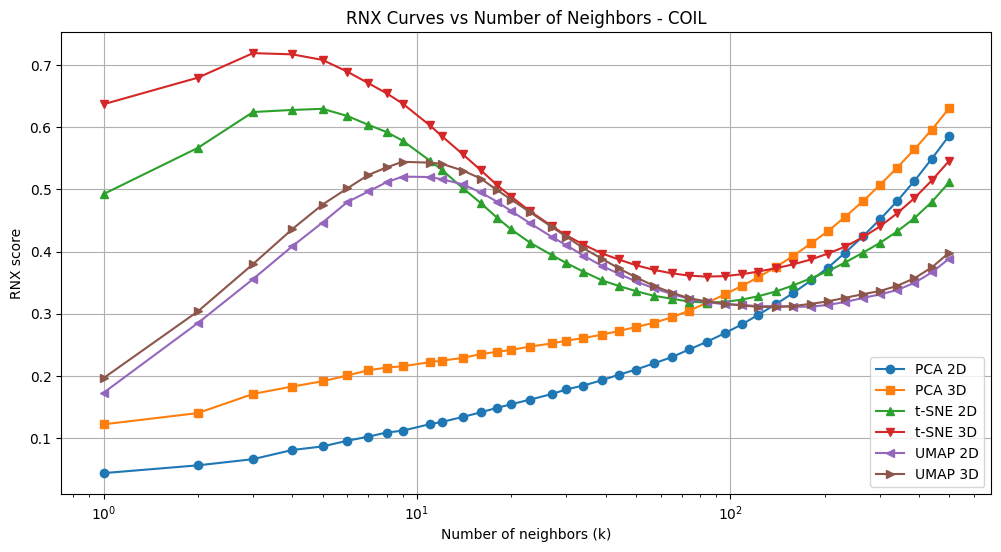

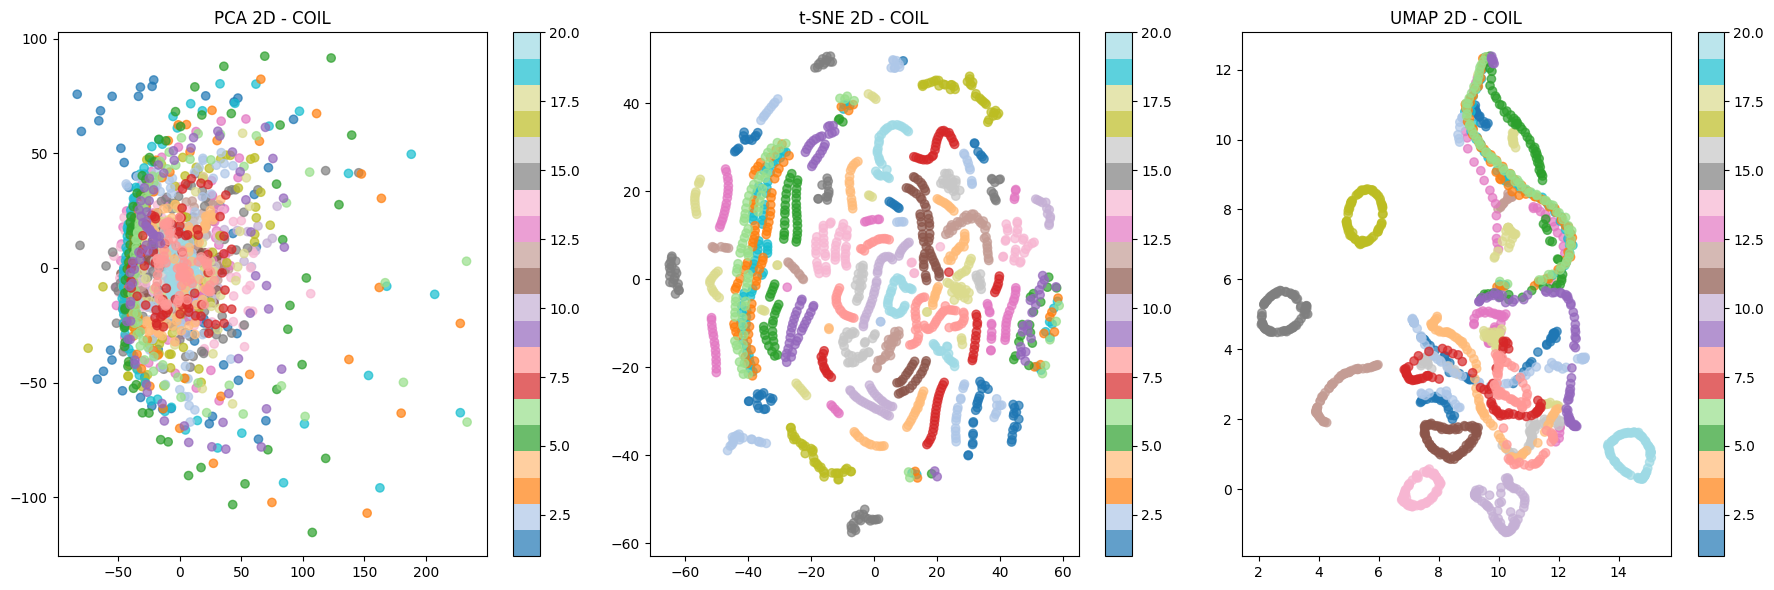

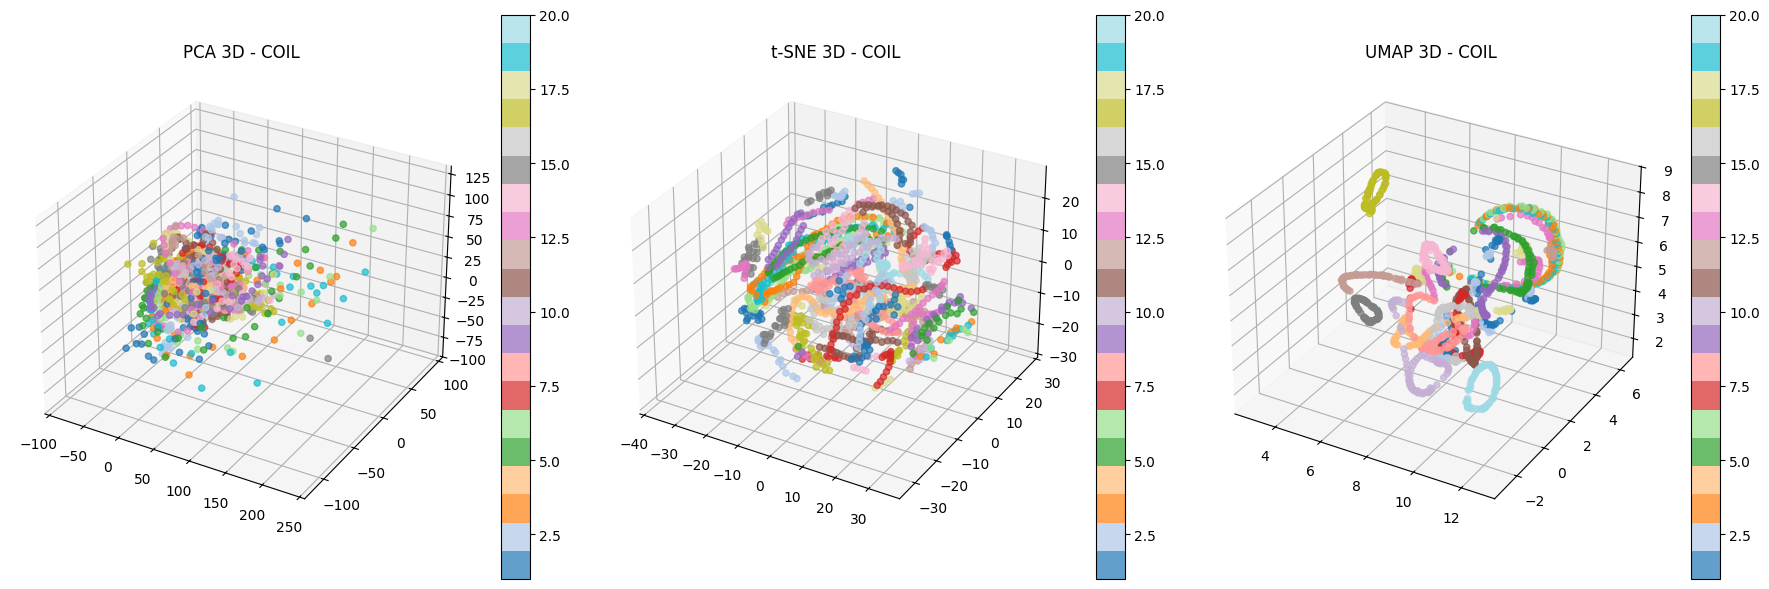

In [32]:
import numpy as np
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Dimensionality reduction
pca = PCA(random_state=42)
pca_2 = pca.fit_transform(scaled_images_coil)[:, :2]
pca_3 = pca.fit_transform(scaled_images_coil)[:, :3]

tsne_2d = TSNE(n_components=2, random_state=42).fit_transform(scaled_images_coil)
tsne_3d = TSNE(n_components=3, random_state=42).fit_transform(scaled_images_coil)

umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(scaled_images_coil)
umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(scaled_images_coil)

# Define RNX computation
def compute_rnx_curve(original_data, reduced_data, k_values):
    nn_original = NearestNeighbors(n_neighbors=np.max(k_values) + 1).fit(original_data)
    nn_reduced = NearestNeighbors(n_neighbors=np.max(k_values) + 1).fit(reduced_data)

    indices_original = nn_original.kneighbors(return_distance=False)[:, 1:]
    indices_reduced = nn_reduced.kneighbors(return_distance=False)[:, 1:]

    rnx_scores = []
    for k in k_values:
        match_counts = [
            len(set(indices_original[i, :k]).intersection(indices_reduced[i, :k]))
            for i in range(original_data.shape[0])
        ]
        rnx_scores.append(np.mean(match_counts) / k)

    return np.array(rnx_scores)

# RNX values for different projections
k_values = np.unique(np.logspace(0, np.log10(500), num=50, dtype=int))

rnx_pca_2d = compute_rnx_curve(scaled_images_coil, pca_2, k_values)
rnx_pca_3d = compute_rnx_curve(scaled_images_coil, pca_3, k_values)
rnx_tsne_2d = compute_rnx_curve(scaled_images_coil, tsne_2d, k_values)
rnx_tsne_3d = compute_rnx_curve(scaled_images_coil, tsne_3d, k_values)
rnx_umap_2d = compute_rnx_curve(scaled_images_coil, umap_2d, k_values)
rnx_umap_3d = compute_rnx_curve(scaled_images_coil, umap_3d, k_values)

# Plot RNX curves
plt.figure(figsize=(12, 6))
plt.semilogx(k_values, rnx_pca_2d, label='PCA 2D', marker='o')
plt.semilogx(k_values, rnx_pca_3d, label='PCA 3D', marker='s')
plt.semilogx(k_values, rnx_tsne_2d, label='t-SNE 2D', marker='^')
plt.semilogx(k_values, rnx_tsne_3d, label='t-SNE 3D', marker='v')
plt.semilogx(k_values, rnx_umap_2d, label='UMAP 2D', marker='<')
plt.semilogx(k_values, rnx_umap_3d, label='UMAP 3D', marker='>')

plt.xlabel('Number of neighbors (k)')
plt.ylabel('RNX score')
plt.title('RNX Curves vs Number of Neighbors - COIL')
plt.legend()
plt.grid(True)
plt.savefig('rnx_curves_vs_k_coil_extended.png')
plt.show()

# 2D Projections
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scatter0 = axes[0].scatter(pca_2[:, 0], pca_2[:, 1], c=[int(label) for label in labels_coil], cmap='tab20', alpha=0.7)
axes[0].set_title('PCA 2D - COIL')
fig.colorbar(scatter0, ax=axes[0])

scatter1 = axes[1].scatter(tsne_2d[:, 0], tsne_2d[:, 1],  c=[int(label) for label in labels_coil], cmap='tab20', alpha=0.7)
axes[1].set_title('t-SNE 2D - COIL')
fig.colorbar(scatter1, ax=axes[1])

scatter2 = axes[2].scatter(umap_2d[:, 0], umap_2d[:, 1],  c=[int(label) for label in labels_coil],  cmap='tab20', alpha=0.7)
axes[2].set_title('UMAP 2D - COIL')
fig.colorbar(scatter2, ax=axes[2])

plt.tight_layout()
plt.savefig('2d_projections_coil.png')
plt.show()

# 3D Projections
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
scatter3 = ax1.scatter(pca_3[:, 0], pca_3[:, 1], pca_3[:, 2],  c=[int(label) for label in labels_coil] , cmap='tab20', alpha=0.7)
ax1.set_title('PCA 3D - COIL')
fig.colorbar(scatter3, ax=ax1)

ax2 = fig.add_subplot(132, projection='3d')
scatter4 = ax2.scatter(tsne_3d[:, 0], tsne_3d[:, 1], tsne_3d[:, 2], c=[int(label) for label in labels_coil], cmap='tab20', alpha=0.7)
ax2.set_title('t-SNE 3D - COIL')
fig.colorbar(scatter4, ax=ax2)

ax3 = fig.add_subplot(133, projection='3d')
scatter5 = ax3.scatter(umap_3d[:, 0], umap_3d[:, 1], umap_3d[:, 2],  c=[int(label) for label in labels_coil], cmap='tab20', alpha=0.7)
ax3.set_title('UMAP 3D - COIL')
fig.colorbar(scatter5, ax=ax3)

plt.tight_layout()
plt.savefig('3d_projections_coil.png')
plt.show()


#  RNX Curve Analysis: COIL vs. MNIST

This document compares RNX (Relative Neighborhood Excess) curves across different dimensionality reduction methods on two datasets: **COIL** and **MNIST**. RNX measures how well a method preserves neighborhood structure after projection to 2D or 3D.

---

##  What is RNX?

- **RNX score** evaluates how well local neighborhoods are preserved after dimensionality reduction.
- The **x-axis** represents the number of neighbors \( k \) (log scale).
- The **y-axis** shows the RNX score (higher is better).

---

##  Dataset 1: COIL

### RNX Curve Observations:

| Method       | Best At                       | Weaknesses                     |
|--------------|-------------------------------|---------------------------------|
| **t-SNE 3D** | Best local structure (high RNX for small \( k \)) | Drops as \( k \) increases     |
| **t-SNE 2D** | Similar to 3D, slightly lower  | Degrades at high \( k \)       |
| **UMAP 2D**  | Strong mid-range \( k \)       | Low small-\( k \) performance   |
| **UMAP 3D**  | Balanced, slightly better than UMAP 2D | Drops slightly at high \( k \) |
| **PCA 3D**   | Best large-\( k \) (global structure) | Poor local fidelity             |
| **PCA 2D**   | Weakest at low \( k \), improves at high \( k \) | Poor local neighborhoods       |

### Insights:
- **t-SNE 3D** is the top choice for **local neighborhood fidelity**.
- **PCA 3D** outperforms others for **global structure**.
- **UMAP** provides a **compromise** between local and global.

---

##  Dataset 2: MNIST

## RNX Curve Observations

| **Method**                | **Best At**                          | **Weaknesses**                        |
|---------------------------|--------------------------------------|----------------------------------------|
| **PCA**                   | Strongest for large \( k \)          | Weak at preserving local structures    |
| **Kernel PCA (RBF)**      | Good global structure                | Low RNX for small \( k \)              |
| **Kernel PCA (Poly)**     | Similar to RBF                       | Very weak at small \( k \)             |
| **t-SNE (perp=5)**        | Best for small \( k \)               | Rapid drop as \( k \) increases        |
| **t-SNE (perp=50)**       | Better global preservation than perp=5 | Slightly lower RNX across the board  |
| **UMAP (n=5)**            | Balanced across \( k \), good for local | Not top-performing at large \( k \) |
| **UMAP (n=50)**           | Improves at large \( k \)            | Low RNX at smallest \( k \)            |

---

##  Key Insights

- **t-SNE (perp=5)** performs **best at small \( k \)** → ideal for **local neighborhood structure**.
- **PCA** and **Kernel PCA** methods steadily improve with \( k \) → effective for **global relationships**.
- **UMAP (n_neighbors=5 and 50)** offers **a good trade-off** between local and global preservation.
- **Kernel PCA (RBF)** slightly outperforms **PCA** at mid-range \( k \), but both are similar for large \( k \).
- **t-SNE (perp=50)** is more stable than perp=5, making it more suitable for **medium- to large-scale** structure.

---


In [33]:
df_original = pd.DataFrame(scaled_images)


In [34]:
df_tsne = pd.DataFrame(tsne_3d_mnist, columns=['t-SNE 1', 't-SNE 2' , "t-SNE 3"])

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 10  # Assuming 10 classes in MNIST
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Apply K-Means on different feature spaces
clusters_original = kmeans.fit_predict(df_original)
clusters_pca = kmeans.fit_predict(df_pca)
clusters_tsne = kmeans.fit_predict(df_tsne)

# Evaluate clustering using silhouette score (higher is better)
scores = {
    "Original": silhouette_score(df_original, clusters_original),
    "PCA": silhouette_score(df_pca, clusters_pca),
    "t-SNE": silhouette_score(df_tsne, clusters_tsne),
}

# Print silhouette scores
print("Silhouette Scores for K-Means Clustering:")
for method, score in scores.items():
    print(f"{method}: {score:.4f}")


Silhouette Scores for K-Means Clustering:
Original: -0.0239
PCA: 0.1144
t-SNE: 0.2351


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Single consistent split index
X_indices = np.arange(len(labels))
train_idx, test_idx = train_test_split(X_indices, test_size=0.2, random_state=42)

# Original space
X_train = scaled_images[train_idx]
X_test = scaled_images[test_idx]
y_train = labels[train_idx]
y_test = labels[test_idx]

# PCA
X_pca = df_pca.drop(columns="label").values
X_train_pca = X_pca[train_idx]
X_test_pca = X_pca[test_idx]

# t-SNE
X_train_tsne = tsne_3d_mnist[train_idx]
X_test_tsne = tsne_3d_mnist[test_idx]

# UMAP
X_train_umap = umap_3d_mnist_result[train_idx]
X_test_umap = umap_3d_mnist_result[test_idx]

# KNN evaluation
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)
acc_original = accuracy_score(y_test, knn.predict(X_test))

knn.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, knn.predict(X_test_pca))

knn.fit(X_train_tsne, y_train)
acc_tsne = accuracy_score(y_test, knn.predict(X_test_tsne))

knn.fit(X_train_umap, y_train)
acc_umap = accuracy_score(y_test, knn.predict(X_test_umap))

print("\nK-NN Accuracy Scores:")
print(f"Original: {acc_original:.4f}")
print(f"PCA: {acc_pca:.4f}")
print(f"t-SNE: {acc_tsne:.4f}")
print(f"UMAP: {acc_umap:.4f}")



K-NN Accuracy Scores:
Original: 0.3583
PCA: 0.5167
t-SNE: 0.4583
UMAP: 0.4333


In [37]:
"""""# Create CNN model
model = tf.keras.Sequential([
    # First convolutional layer
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Second convolutional layer
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Third convolutional layer
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Flatten layer
    tf.keras.layers.Flatten(),
    
    # Dense layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Prepare data
X = np.array([img for images in images_mnist.values() for img in images])
y = np.array([int(label) for label, images in images_mnist.items() for _ in range(len(images))])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
history = model.fit(X_train, y_train,
                   epochs=10,
                   batch_size=32,
                   validation_data=(X_test, y_test))
"""""""""

'""# Create CNN model\nmodel = tf.keras.Sequential([\n    # First convolutional layer\n    tf.keras.layers.Conv2D(32, (3, 3), activation=\'relu\', input_shape=(224, 224, 3)),\n    tf.keras.layers.MaxPooling2D((2, 2)),\n    \n    # Second convolutional layer\n    tf.keras.layers.Conv2D(64, (3, 3), activation=\'relu\'),\n    tf.keras.layers.MaxPooling2D((2, 2)),\n    \n    # Third convolutional layer\n    tf.keras.layers.Conv2D(64, (3, 3), activation=\'relu\'),\n    tf.keras.layers.MaxPooling2D((2, 2)),\n    \n    # Flatten layer\n    tf.keras.layers.Flatten(),\n    \n    # Dense layers\n    tf.keras.layers.Dense(128, activation=\'relu\'),\n    tf.keras.layers.Dropout(0.5),\n    tf.keras.layers.Dense(10, activation=\'softmax\')  # 10 classes for MNIST\n])\n\n# Compile the model\nmodel.compile(optimizer=\'adam\',\n              loss=\'sparse_categorical_crossentropy\',\n              metrics=[\'accuracy\'])\n\n# Prepare data\nX = np.array([img for images in images_mnist.values() for img i

In [39]:
k = 5  # Choose an appropriate k for KNN

# Split the COIL-20 data

X_train, X_test, y_train, y_test = train_test_split(scaled_images_coil, labels_coil, test_size=0.2, random_state=42)

# Split PCA, t-SNE, and UMAP transformed data using same train/test indices
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(pca_10_coil, labels_coil, test_size=0.2, random_state=42)
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(tsne_3d, labels_coil, test_size=0.2, random_state=42)
X_train_umap, X_test_umap, y_train_umap, y_test_umap = train_test_split(umap_3d,  labels_coil, test_size=0.2, random_state=42)

# Train K-NN on different feature spaces
knn = KNeighborsClassifier(n_neighbors=k)

# Original space
knn.fit(X_train, y_train)
acc_original = accuracy_score(y_test, knn.predict(X_test))

# PCA space
knn.fit(X_train_pca, y_train_pca)
acc_pca = accuracy_score(y_test_pca, knn.predict(X_test_pca))

# t-SNE space
knn.fit(X_train_tsne, y_train_tsne)
acc_tsne = accuracy_score(y_test_tsne, knn.predict(X_test_tsne))

# UMAP space
knn.fit(X_train_umap, y_train_umap)
acc_umap = accuracy_score(y_test_umap, knn.predict(X_test_umap))

# Print accuracy scores
print("\nK-NN Accuracy Scores for COIL-20:")
print(f"Original: {acc_original:.4f}")
print(f"PCA: {acc_pca:.4f}")
print(f"t-SNE: {acc_tsne:.4f}")
print(f"UMAP: {acc_umap:.4f}")


K-NN Accuracy Scores for COIL-20:
Original: 0.9167
PCA: 0.8403
t-SNE: 0.8924
UMAP: 0.7708


#  Comparative Analysis: MNIST vs COIL-20

##  1. MNIST Dataset

###  K-NN Accuracy Scores
| Space       | Accuracy |
|-------------|----------|
| Original    | 35.83%   |
| PCA         | **51.67%** |
| t-SNE       | 45.83%   |
| UMAP        | 43.33%   |

###  Silhouette Scores (K-Means Clustering)
| Space       | Silhouette Score |
|-------------|------------------|
| Original    | **-0.0239**  |
| PCA         | 0.1147 |
| t-SNE       | **0.2351**  |

**Interpretation:**
- The original space is not well-structured for clustering or classification.
- **PCA** performs best for K-NN classification.
- **t-SNE** captures the best cluster structure.
- UMAP performs moderately in both tasks.

---

##  2. COIL-20 Dataset

###  K-NN Accuracy Scores
| Space       | Accuracy |
|-------------|----------|
| Original    | **91.67%**  |
| PCA         | 84.03%   |
| t-SNE       | 89.24%   |
| UMAP        | 77.08%   |

**Interpretation:**
- The **original space is already highly separable**; dimensionality reduction is not beneficial for classification.
- **t-SNE** maintains the structure quite well.
- **UMAP** struggles, possibly due to the low number of images per class.
- PCA reduces performance slightly.

---

##  Summary Table

| Dataset  | Technique | K-NN Accuracy | Silhouette Score | Insight |
|----------|-----------|---------------|------------------|---------|
| MNIST    | Original  | 35.83%        | -0.0239          | Raw data too complex |
| MNIST    | PCA       | **51.67%**    | 0.1147           | Best for classification |
| MNIST    | t-SNE     | 45.83%        | **0.2351** ✅    | Best for clustering |
| MNIST    | UMAP      | 43.33%        | —                | Moderate performance |
| COIL-20  | Original  | **91.67%** ✅ | —                | Best, no need for reduction |
| COIL-20  | PCA       | 84.03%        | —                | Loses key details |
| COIL-20  | t-SNE     | 89.24%        | —                | Keeps good structure |
| COIL-20  | UMAP      | 77.08%        | —                | Underperforms |

---



# Project Analysis and Interpretation

## Dataset Overview
- Two main datasets were used in this project:
    - MNIST Dataset: Handwritten digit images
    - COIL-20 Dataset: 20 different objects photographed from various angles

## Data Preprocessing
1. Image Processing:
     - All images were resized to 224x224 pixels
     - Converted to RGB format
     - Flattened and standardized using StandardScaler

## Dimensionality Reduction Analysis

### PCA Results
- Applied 2D and 3D PCA to both datasets
- COIL-20 showed better class separation in PCA projections
- Preserved global structure but lost some local relationships
- Explained variance ratio suggests good data compression

### t-SNE Results
- Showed superior local structure preservation compared to PCA
- 2D and 3D visualizations revealed clear cluster formations
- Better at preserving local relationships between similar images
- Computation time was longer than PCA

### UMAP Results
- Combined benefits of PCA and t-SNE
- Maintained both global and local structure
- Showed clear cluster separation
- Faster computation than t-SNE

## Performance Metrics

### Classification Performance (KNN)
1. MNIST Dataset:
     - Original space: 35.83% accuracy
     - PCA: Best performer with 51.67% accuracy
     - t-SNE: Strong clustering with 45.83% accuracy
     - UMAP: Moderate 43.33% accuracy

2. COIL-20 Dataset:
     - Original space: Best performance at 91.67% accuracy
     - PCA: Slight degradation to 84.03% accuracy
     - t-SNE: Near-original performance at 89.24% accuracy
     - UMAP: Lower performance at 77.08% accuracy

### RNX Curve Analysis
- Shows quality of dimensionality reduction
- t-SNE and UMAP maintained better neighborhood preservation
- PCA showed lower RNX scores but faster computation

## Conclusions
1. Method Selection:
     - PCA: Best for fast, linear dimensionality reduction
     - t-SNE: Best for detailed visualization and cluster analysis
     - UMAP: Good balance between performance and speed

2. Dataset Characteristics:
     - COIL-20: More structured, easier to separate
     - MNIST: More complex internal structure

3. Trade-offs:
     - Computation time vs. accuracy
     - Global vs. local structure preservation
     - Dimensionality vs. information preservation